# Data Visualisation & Diagnostics Cheatsheet

Companion reference to `ml_pipelines.ipynb`. Every entry answers three questions:

1. **What it shows** — the question the plot is built to answer
2. **How to read it** — what to actually look at, and what conclusion follows
3. **Fails when** — the conditions under which the plot lies to you

## Contents

| Part | Section | Use it for |
|---|---|---|
| A | Plot selection map | Picking the right chart from the question you're asking |
| A-X | Pipeline stage cross-reference | Jumping from a stage in `ml_pipelines.ipynb` to the plot that informs it |
| B | Per-plot entries | Code, interpretation, and failure modes for each chart |
| C | Statistical layer | The tests and quantities that back up what the plot suggests |
| D | ML diagnostic plots | Model fitting, tuning, evaluation, interpretation |

Run the two setup cells first — every code cell below depends on them.

## Setup

Imports and global plot defaults. Setting these once at the top means every plot below is legible without per-figure fiddling.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

sns.set_theme(style="whitegrid", context="notebook")   # grid + sensible font scaling
plt.rcParams["figure.figsize"] = (8, 5)                 # default canvas; override per-figure as needed
plt.rcParams["figure.dpi"] = 110                        # crisper inline rendering
plt.rcParams["axes.titlesize"] = 12
pd.set_option("display.max_columns", 60)

RNG = np.random.default_rng(42)                         # seeded generator; reproducible synthetic data

### Demo data

Three frames so every plot type has something meaningful to render:

| Frame | Shape | Purpose |
|---|---|---|
| `df_clf` | 569 x 31 | All-numeric binary classification, mild imbalance (~37/63) |
| `df_reg` | 442 x 11 | All-numeric regression target |
| `df_mix` | 800 x 8 | Categoricals, skewed feature, missingness, timestamps, ~8% positive rate |

`df_mix` is constructed deliberately: `pressure` is right-skewed, `pressure` has random gaps, `thickness` has gaps concentrated in one category (structured missingness), and `fail` is rare. Those are the conditions that break naive plots.

In [2]:
from sklearn.datasets import load_breast_cancer, load_diabetes

# --- Numeric classification frame -------------------------------------------
bc = load_breast_cancer(as_frame=True)
df_clf = bc.frame.rename(columns={"target": "y"})

# --- Numeric regression frame -----------------------------------------------
db = load_diabetes(as_frame=True)
df_reg = db.frame.rename(columns={"target": "y"})

# --- Mixed frame: categoricals, skew, missingness, time ----------------------
n = 800
df_mix = pd.DataFrame({
    "tool":      RNG.choice(["TOOL_A", "TOOL_B", "TOOL_C", "TOOL_D"], n, p=[.45, .30, .15, .10]),
    "shift":     RNG.choice(["Day", "Night"], n),
    "recipe":    RNG.choice([f"R{i:02d}" for i in range(12)], n),
    "thickness": RNG.normal(250, 12, n),
    "pressure":  RNG.lognormal(2.0, 0.45, n),      # lognormal => right-skewed on purpose
})

# Non-linear relationship: yield peaks at thickness ~250 and falls off either side
df_mix["yield_pct"] = (92 - 0.005 * (df_mix["thickness"] - 250) ** 2
                       + RNG.normal(0, 1.5, n)).clip(0, 100)
df_mix["fail"] = (df_mix["yield_pct"] < df_mix["yield_pct"].quantile(0.08)).astype(int)

# Missingness injected AFTER the target is computed, so the signal stays intact
df_mix.loc[RNG.choice(n, 90, replace=False), "pressure"] = np.nan   # missing at random
df_mix.loc[df_mix["tool"].eq("TOOL_D"), "thickness"] = np.nan       # structured: one tool never reports
df_mix["ts"] = pd.date_range("2026-01-01", periods=n, freq="3h")

print(df_mix.shape, "| positive rate:", round(df_mix["fail"].mean(), 3))
df_mix.head()

(800, 8) | positive rate: 0.08


,tool,shift,recipe,thickness,pressure,yield_pct,fail,ts
0,TOOL_C,Day,R00,245.295522,14.976755,91.811988,0,2026-01-01 00:00:00
1,TOOL_A,Night,R06,251.679092,4.715662,92.805904,0,2026-01-01 03:00:00
2,TOOL_C,Night,R08,240.201099,6.305869,92.352102,0,2026-01-01 06:00:00
3,TOOL_B,Day,R06,236.238015,9.171955,92.067961,0,2026-01-01 09:00:00
4,TOOL_A,Day,R04,238.717345,23.089018,90.396218,0,2026-01-01 12:00:00


## Part A — Plot Selection Map

### A1. What you're asking to which plot

| What you're asking | Plot | Call | Reads out |
|---|---|---|---|
| Shape of one numeric variable | Histogram | `sns.histplot(df, x=col, bins=30)` | Modality, skew, gaps, spikes at defaults |
| Shape, smoothed | KDE | `sns.kdeplot(df, x=col, fill=True)` | Bimodality that binning may hide |
| Exact percentile lookup | ECDF | `sns.ecdfplot(df, x=col)` | Median, quantiles, no bin-width bias |
| Spread + outliers, compactly | Box plot | `sns.boxplot(df, x=col)` | Median, IQR, fence outliers |
| Spread + shape together | Violin | `sns.violinplot(df, x=col)` | Box statistics plus density |
| Frequency of one categorical | Count plot | `sns.countplot(df, y=col, order=...)` | Level balance, rare levels |
| Two numeric variables | Scatter | `sns.scatterplot(df, x=a, y=b)` | Direction, form, strength, outliers |
| Two numeric, with trend | Reg plot | `sns.regplot(df, x=a, y=b, lowess=True)` | Linear vs curved relationship |
| Two numeric, heavy overplotting | 2D histogram | `sns.histplot(df, x=a, y=b, bins=50, cbar=True)` | Density where scatter becomes a blob |
| Two numeric + marginals | Joint plot | `sns.jointplot(df, x=a, y=b, kind='hex')` | Joint and marginal shape at once |
| Numeric across groups | Box plot | `sns.boxplot(df, x=cat, y=num)` | Group medians, spread, outliers |
| Numeric across groups, small n | Strip / swarm | `sns.stripplot(df, x=cat, y=num, jitter=0.2)` | Every observation, nothing summarised |
| Group means with uncertainty | Bar / point plot | `sns.barplot(df, x=cat, y=num, errorbar=('ci', 95))` | Mean and CI |
| Two categoricals | Grouped count | `sns.countplot(df, x=a, hue=b)` | Conditional composition |
| Two categoricals, many levels | Crosstab heatmap | `sns.heatmap(pd.crosstab(df[a], df[b]), annot=True, fmt='d')` | Cell concentration, empty combinations |
| All pairs at once | Pair plot | `sns.pairplot(df, hue=target, corner=True)` | Fast structural scan; keep to <10 columns |
| Linear association matrix | Correlation heatmap | `sns.heatmap(df.corr(numeric_only=True), cmap='coolwarm', center=0)` | Redundant feature pairs |
| Association matrix, reordered | Cluster map | `sns.clustermap(df.corr(numeric_only=True), cmap='coolwarm', center=0)` | Blocks of mutually correlated features |
| Ordered / time series | Line plot | `sns.lineplot(df, x=t, y=col)` | Trend, seasonality, level shifts |
| Trend under noise | Rolling mean | `df[col].rolling(30).mean().plot()` | Signal beneath short-term variation |
| Where data is missing | Missingness matrix | `sns.heatmap(df.isna(), cbar=False)` | Random vs structured gaps |
| How much is missing | Missingness bar | `df.isna().mean().sort_values().plot.barh()` | Per-column completeness ranking |
| Feature vs binary target | Overlaid KDE | `sns.kdeplot(df, x=feat, hue=target, common_norm=False)` | Class separability of that feature |
| Feature vs continuous target | Scatter + trend | `sns.regplot(df, x=feat, y=target, lowess=True)` | Whether a linear term will do |

### A2. Choosing between near-substitutes

| Situation | Prefer | Over | Reason |
|---|---|---|---|
| Suspect two subpopulations | KDE or violin | Box plot | A box plot shows one median and hides bimodality entirely |
| Comparing more than 5 groups | Box plot | Violin | Violins get visually noisy and consume too much width |
| n < 30 per group | Strip / swarm | Box plot | Quartiles are unstable at small n; show the points |
| More than 5,000 points | 2D histogram | Scatter | Overplotting hides density; a solid blob says nothing |
| Ordinal categories | Line or point plot | Bar plot | Bars imply independent categories, lines imply order |
| Comparing distribution shapes | ECDF | Histogram | No bin-width choice to bias the comparison |
| More than 15 features | Correlation heatmap | Pair plot | Pair plot becomes unreadable and slow past ~10 columns |
| Strictly positive quantity | Histogram | KDE | KDE smooths mass below zero, which is impossible |

## Part A-X — Pipeline Stage Cross-Reference

The bridge between `ml_pipelines.ipynb` and this cheatsheet. Each row: where you are in the pipeline, what to plot, and the decision it forces.

### Stage 1 — Data understanding

| Stage | Plot | Decision it drives | Section |
|---|---|---|---|
| First look | Histogram grid: `df.hist(figsize=(16,12), bins=30)` | Constant columns, impossible values, wrong dtypes, sentinel codes like -999 | B1 |
| Missingness | Missingness matrix and correlation of null flags | Drop vs impute; whether missingness is structured and should become a feature | B13 |
| Target balance | `sns.countplot(df, x=target)` | Metric choice, `class_weight`, resampling, threshold tuning | B3, C6 |
| Cardinality | Bar of `df.select_dtypes('object').nunique()` | One-hot vs ordinal vs target encoding; whether to group rare levels | B3 |

### Stage 2 — Preprocessing decisions

| Stage | Plot | Decision it drives | Section |
|---|---|---|---|
| Skew | Histogram + QQ plot | Log / sqrt / Yeo-Johnson, or leave it if using trees | C1, C2 |
| Outliers | Box plot per feature | Clip, winsorise, drop, or keep — linear and distance-based models care, trees mostly do not | B2, C5 |
| Scale disparity | Box plot of all numeric features on shared axes | Whether scaling is required at all | C7 |
| Multicollinearity | Correlation heatmap + VIF bar chart | Drop one of each pair, apply PCA, or switch to a regularised or tree model | B11, C4 |
| Dimensionality | PCA scree + cumulative explained variance | How many components to retain | D13 |

### Stage 3 — Split and leakage checks

| Stage | Plot | Decision it drives | Section |
|---|---|---|---|
| Split sanity | Overlaid train vs test KDE per feature | Detect a non-random split or drift before blaming the model | B8 |
| Leakage suspicion | Top-importance feature vs target scatter | Near-perfect separation is usually leakage, not skill | D9 |

### Stage 4 — Model fitting and tuning

| Stage | Plot | Decision it drives | Section |
|---|---|---|---|
| Bias vs variance | Learning curve | More data, more capacity, or more regularisation | D1 |
| Parameter sensitivity | Validation curve | Which hyperparameters matter and where overfitting starts | D2 |
| Search convergence | Optuna optimisation history | Whether to extend the search or stop | D11 |
| Search focus | Optuna parameter importances | Which parameters to keep tuning, which to freeze | D11 |

### Stage 5 — Evaluation

| Stage | Plot | Decision it drives | Section |
|---|---|---|---|
| Error type balance | Confusion matrix | Whether the errors are the affordable kind | D3 |
| Ranking quality | ROC curve | Overall separability — balanced classes only | D4 |
| Ranking quality, imbalanced | Precision-recall curve | The honest view when positives are rare | D5 |
| Operating point | Precision and recall vs threshold | Where to set the cutoff instead of defaulting to 0.5 | D6 |
| Probability quality | Calibration curve | Whether to wrap the model in Platt or isotonic calibration | D7 |
| Regression fit | Residual vs fitted, QQ, scale-location, pred vs actual | Heteroscedasticity, unmodelled non-linearity, systematic bias | D8 |

### Stage 6 — Interpretation

| Stage | Plot | Decision it drives | Section |
|---|---|---|---|
| Which features matter | Permutation importance | Trustworthy ranking; impurity importance is biased | D9 |
| Direction and magnitude | SHAP beeswarm | Whether effects match domain expectation | D9 |
| Shape of an effect | Partial dependence + ICE | Whether a linear term suffices, and whether the average hides subgroup reversals | D10 |

### Stage 7 — Unsupervised

| Stage | Plot | Decision it drives | Section |
|---|---|---|---|
| Choosing k | Elbow plot of inertia | Rough upper bound on k | D12 |
| Cluster quality | Silhouette plot per cluster | Whether clusters are separated or forced | D12 |
| Hierarchy | Dendrogram | Natural cut height and nesting structure | D12 |
| Cluster inspection | PCA scatter coloured by label | Whether clustering agrees with visible structure | D13 |

## Part B — Per-Plot Entries

Each entry: what it shows, how to read it, and the conditions under which it misleads.

### B1. Histogram / KDE / ECDF — distribution shape

**What it shows.** Where the mass of a single numeric variable sits, and how it is shaped.

**How to read it.**

| Feature of the plot | What it means | What you do about it |
|---|---|---|
| One peak, roughly symmetric | Well-behaved variable | Nothing |
| Two or more peaks | A hidden grouping variable is mixed in | Find the grouping column and split or add it as a feature |
| Long right tail | Right skew | Consider log / Yeo-Johnson if using a linear or distance-based model |
| Tall spike at a single value | Sentinel code, floor effect, or default fill | Investigate before imputing — that value may mean "missing" |
| Gaps with zero mass | Upstream filtering | Confirm the filter is intentional and applies at inference time too |

**Fails when.**

- **Histogram:** bin width invents or erases modes. Always test at least two bin counts before concluding anything about modality.
- **KDE:** smooths across hard boundaries and places mass below zero for strictly positive quantities. Default bandwidth oversmooths, which can flatten genuine bimodality into one hump.
- **ECDF:** unbiased and bin-free, but shape is much harder to see by eye than in a histogram.

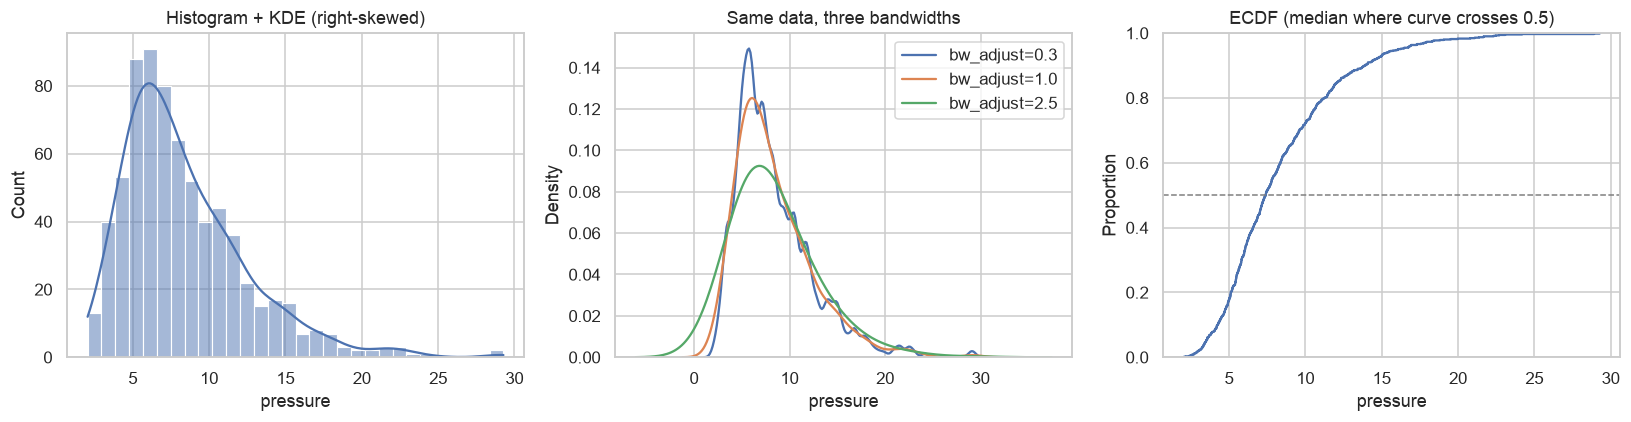

In [3]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Histogram: kde=True overlays the smoothed curve on the same axis scale
sns.histplot(df_mix, x="pressure", bins=30, kde=True, ax=axes[0])
axes[0].set_title("Histogram + KDE (right-skewed)")

# Bandwidth sensitivity: bw_adjust <1 = less smoothing, >1 = more
for bw in [0.3, 1.0, 2.5]:
    sns.kdeplot(df_mix, x="pressure", bw_adjust=bw, label=f"bw_adjust={bw}", ax=axes[1])
axes[1].legend(); axes[1].set_title("Same data, three bandwidths")

# ECDF: read any quantile straight off the y-axis, no binning decision
sns.ecdfplot(df_mix, x="pressure", ax=axes[2])
axes[2].axhline(0.5, ls="--", c="grey", lw=1)   # median reference line
axes[2].set_title("ECDF (median where curve crosses 0.5)")

plt.tight_layout(); plt.show()

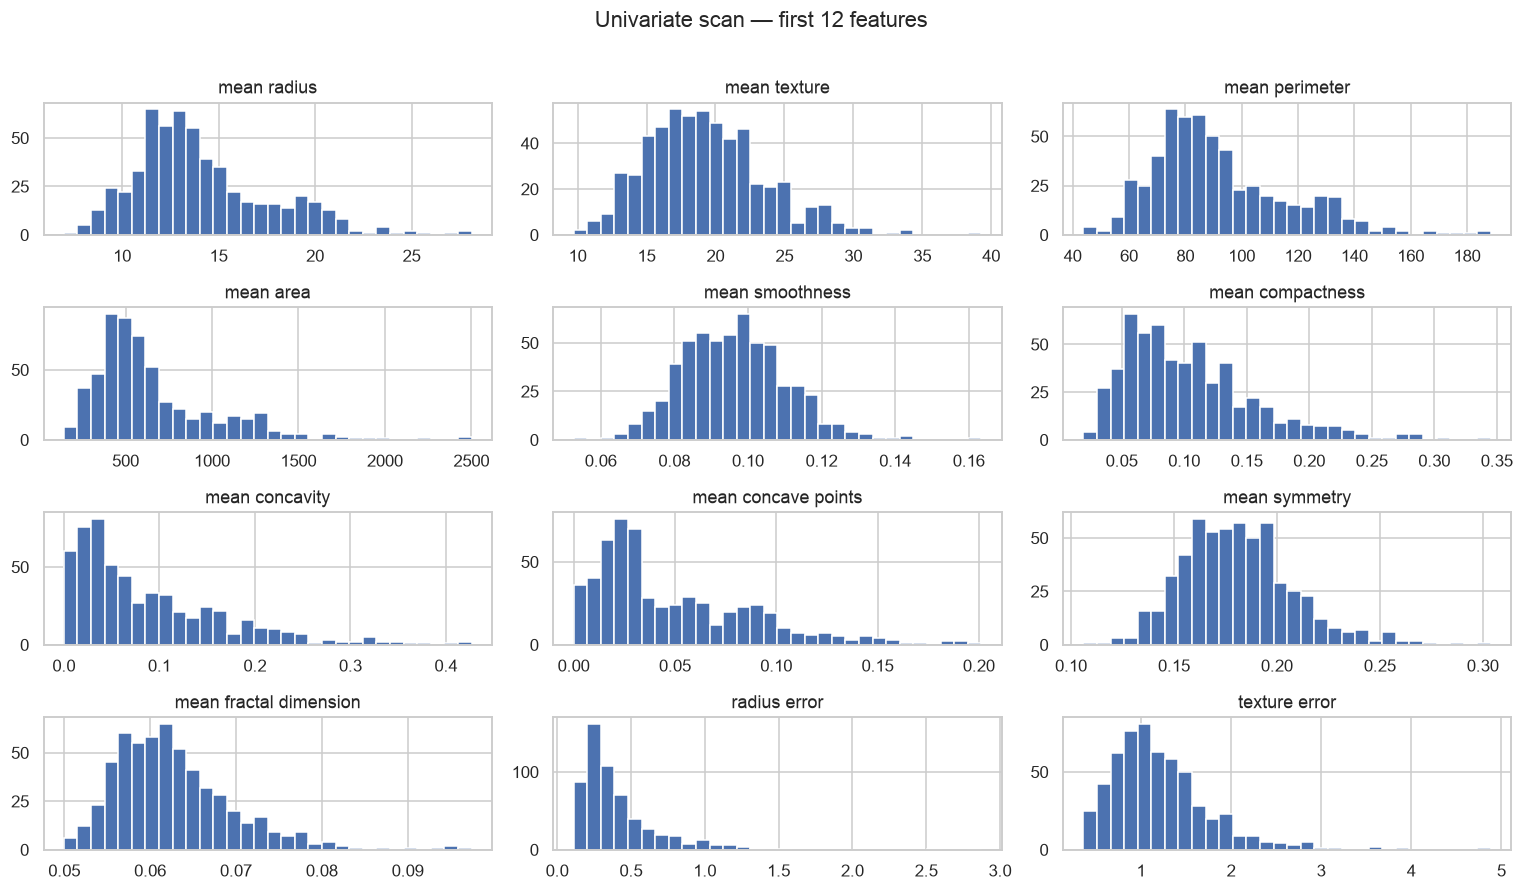

In [4]:
# Fast whole-frame scan. Do this first on any new dataset — it exposes
# constant columns, sentinel spikes and impossible ranges in one pass.
df_clf.iloc[:, :12].hist(figsize=(14, 8), bins=30, edgecolor="white")
plt.suptitle("Univariate scan — first 12 features", y=1.01)
plt.tight_layout(); plt.show()

### B2. Box plot / Violin — spread and outliers

**What it shows.** The five-number summary (min, Q1, median, Q3, max) plus points beyond the whisker fences.

**How to read it.**

| Feature of the plot | What it means |
|---|---|
| Median line off-centre in the box | Skew — toward the shorter half |
| One whisker much longer | Tail on that side |
| Dots beyond the whiskers | Points outside `Q1 - 1.5*IQR` or `Q3 + 1.5*IQR` |
| Box very narrow | Low variance — check the feature is not near-constant |

The dots are **fence outliers**, not errors. For a normal distribution roughly 0.7% of points fall outside the fences by construction, so a handful of dots in a large sample is expected, not a defect.

**Fails when.**

- Bimodal data produces a box plot indistinguishable from unimodal data. This is the single most common way a box plot lies. Pair with a violin or KDE before trusting it.
- At n < 20 per group the quartiles are unstable and the box moves noticeably with one added point.
- Violins render density below a physical minimum (negative pressure, negative count). Use `cut=0` to clip the kernel at the observed data range.

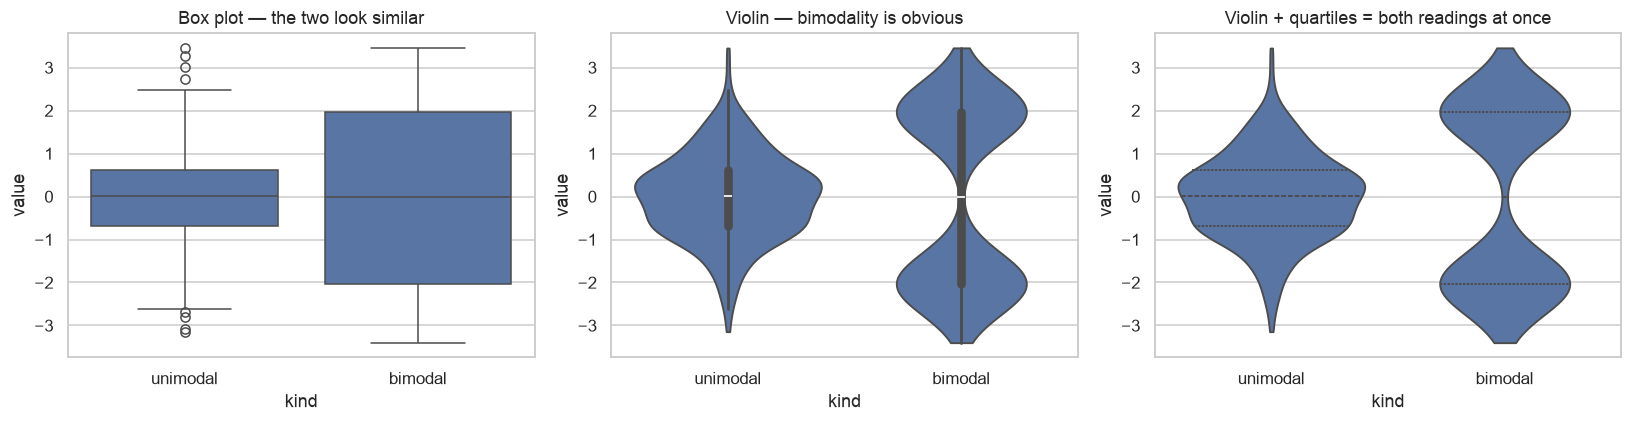

In [5]:
# Constructed demo: identical medians and quartiles, completely different shapes
uni = RNG.normal(0, 1, 600)
bim = np.concatenate([RNG.normal(-2, 0.45, 300), RNG.normal(2, 0.45, 300)])
demo = pd.DataFrame({"value": np.r_[uni, bim],
                     "kind": ["unimodal"] * 600 + ["bimodal"] * 600})

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

sns.boxplot(demo, x="kind", y="value", ax=axes[0])
axes[0].set_title("Box plot — the two look similar")

# cut=0 stops the kernel extending past the observed min/max
sns.violinplot(demo, x="kind", y="value", cut=0, ax=axes[1])
axes[1].set_title("Violin — bimodality is obvious")

# inner="quart" draws the quartile lines inside the violin body
sns.violinplot(demo, x="kind", y="value", cut=0, inner="quart", ax=axes[2])
axes[2].set_title("Violin + quartiles = both readings at once")

plt.tight_layout(); plt.show()

### B3. Count plot — categorical frequency and target balance

**What it shows.** How many rows sit in each level of a categorical column.

**How to read it.**

- **Ordering matters.** Sort by frequency for nominal categories; keep natural order for ordinal ones.
- **Rare levels** (under ~1% of rows, or fewer than ~30 absolute) will not survive a train/test split intact. Group them into `Other` before encoding.
- **On the target**, this is your imbalance check. The majority-class rate is the accuracy your model must beat to be worth anything.

**Fails when.**

- The x-axis is truncated or the bars are sorted arbitrarily, making small differences look large or ordered categories look nominal.
- High-cardinality columns (12+ levels) produce unreadable label collisions — switch to horizontal bars, or plot only the top N with the remainder aggregated.

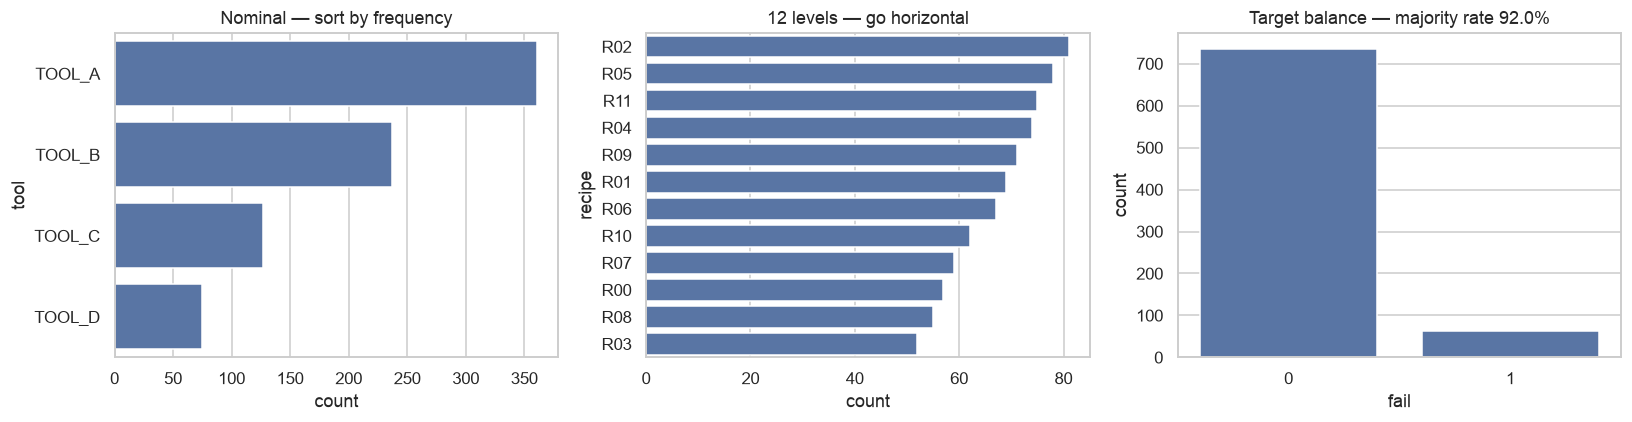

recipe    12
tool       4
shift      2
dtype: int64


In [6]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# order= by value_counts index gives a descending, readable bar order
sns.countplot(df_mix, y="tool", order=df_mix["tool"].value_counts().index, ax=axes[0])
axes[0].set_title("Nominal — sort by frequency")

# Horizontal bars for high cardinality; labels stay legible
sns.countplot(df_mix, y="recipe", order=df_mix["recipe"].value_counts().index, ax=axes[1])
axes[1].set_title("12 levels — go horizontal")

sns.countplot(df_mix, x="fail", ax=axes[2])
axes[2].set_title(f"Target balance — majority rate {1 - df_mix['fail'].mean():.1%}")

plt.tight_layout(); plt.show()

# Cardinality audit: drives the encoding decision for every categorical column.
# exclude="number" is safer than include="object" across pandas versions.
print(df_mix.select_dtypes(exclude=["number", "datetime"])
      .nunique().sort_values(ascending=False))

### B4. Scatter / reg plot — two numeric variables

**What it shows.** The joint behaviour of two numeric variables. Read it in four passes: **direction, form, strength, outliers.**

**How to read it.**

| Pass | Question | Consequence |
|---|---|---|
| Direction | Up, down, or flat? | Sign of the relationship |
| Form | Straight, curved, stepped? | Whether a linear term is enough |
| Strength | Tight band or diffuse cloud? | How much of the target this feature can explain |
| Outliers | Points far off the pattern? | High-leverage rows that will drag an OLS fit |

Overlay a LOWESS curve next to the straight fit. If the two diverge, the relationship is non-linear and you need a transform, a spline, or a tree-based model.

**Fails when.**

- **Overplotting.** Past a few thousand points the cloud saturates and density is invisible. Move to B5.
- **Simpson's paradox.** A lurking categorical can reverse the apparent trend. Always re-plot with `hue=` set to your main grouping column before believing a slope.
- The shaded band on `regplot` is the confidence interval **of the mean line**, not a prediction interval for individual points. It is much narrower than where new data will land.

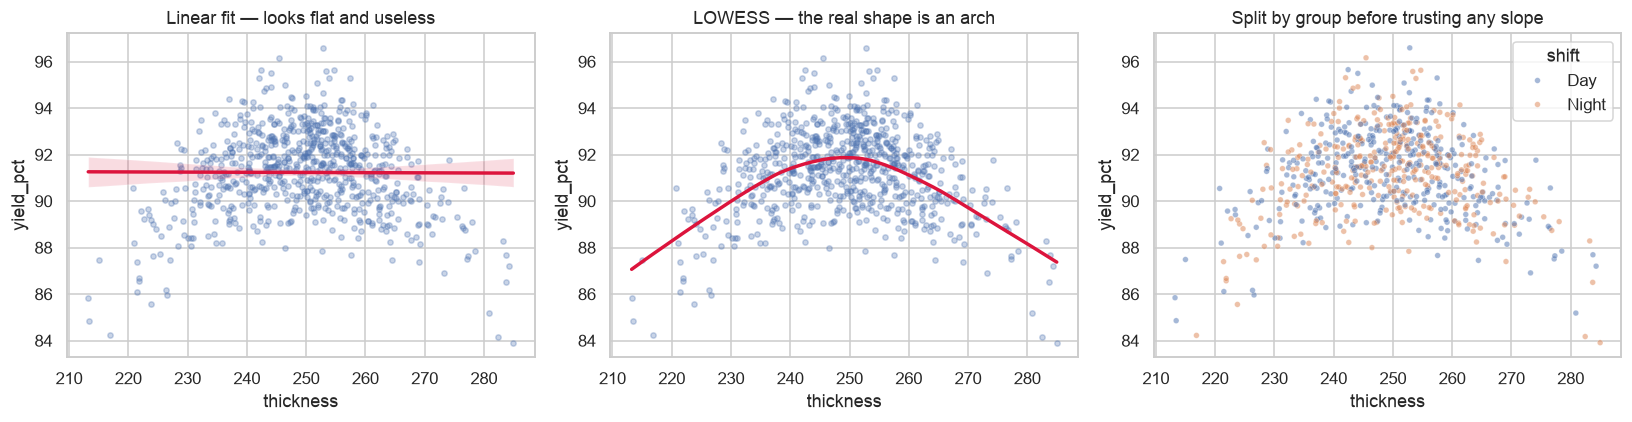

In [7]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

sns.regplot(df_mix, x="thickness", y="yield_pct",
            scatter_kws={"alpha": .3, "s": 12}, line_kws={"color": "crimson"}, ax=axes[0])
axes[0].set_title("Linear fit — looks flat and useless")

# lowess=True fits a local regression; divergence from the straight line = non-linearity
sns.regplot(df_mix, x="thickness", y="yield_pct", lowess=True,
            scatter_kws={"alpha": .3, "s": 12}, line_kws={"color": "crimson"}, ax=axes[1])
axes[1].set_title("LOWESS — the real shape is an arch")

# hue= splits by a grouping variable; the guard against Simpson's paradox
sns.scatterplot(df_mix, x="thickness", y="yield_pct", hue="shift", alpha=.5, s=14, ax=axes[2])
axes[2].set_title("Split by group before trusting any slope")

plt.tight_layout(); plt.show()

### B5. 2D histogram / hexbin / joint plot — dense numeric pairs

**What it shows.** Where the *density* of points is, when a scatter plot has saturated into a solid blob.

**How to read it.** Colour is count per bin. Look for multiple density cores (subpopulations), diagonal ridges (a deterministic relationship plus noise), and empty wedges (constraint boundaries — often a physical or business rule).

**Fails when.**

- Bin count too coarse hides structure; too fine turns the plot back into a noisy scatter.
- A linear colour scale is dominated by one very dense cell, washing everything else to the background colour. Use a log-scaled norm when the density range is wide.

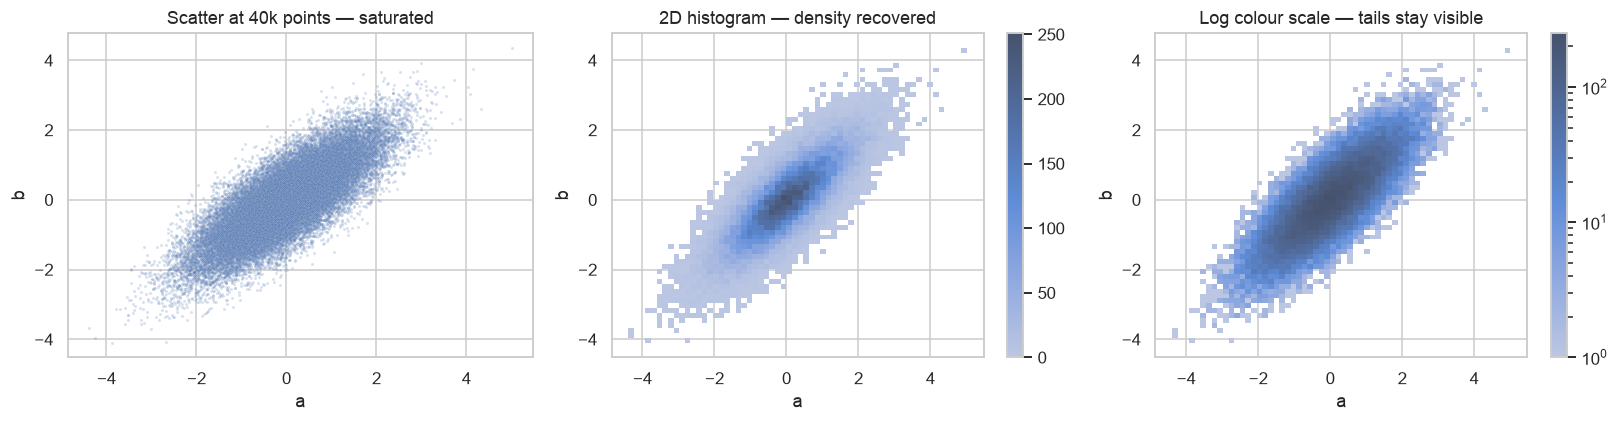

In [8]:
import matplotlib.colors as mcolors

big = pd.DataFrame({"a": RNG.normal(0, 1, 40_000)})
big["b"] = big["a"] * 0.8 + RNG.normal(0, 0.6, 40_000)

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

sns.scatterplot(big, x="a", y="b", s=4, alpha=.2, ax=axes[0])
axes[0].set_title("Scatter at 40k points — saturated")

sns.histplot(big, x="a", y="b", bins=60, cbar=True, ax=axes[1])
axes[1].set_title("2D histogram — density recovered")

# LogNorm keeps low-density regions visible when one cell dominates.
# vmin/vmax must be set to None: seaborn passes them by default and
# matplotlib rejects a norm supplied alongside explicit limits.
sns.histplot(big, x="a", y="b", bins=60, cbar=True,
             norm=mcolors.LogNorm(), vmin=None, vmax=None, ax=axes[2])
axes[2].set_title("Log colour scale — tails stay visible")

plt.tight_layout(); plt.show()

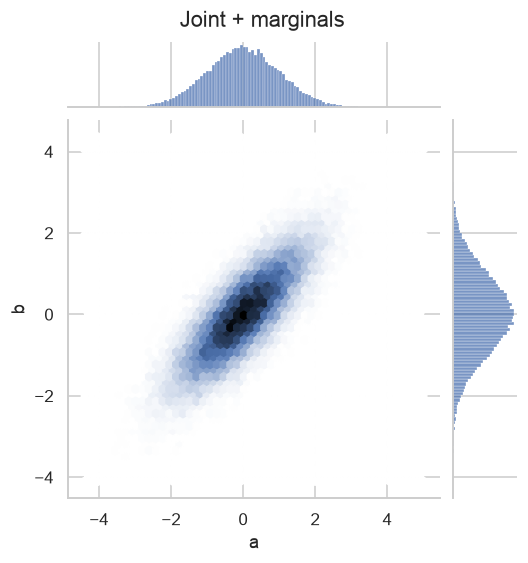

In [9]:
# Joint plot: joint density plus both marginals in one figure.
# Returns a JointGrid, so it manages its own figure — do not pass ax=.
g = sns.jointplot(big, x="a", y="b", kind="hex", height=5)
g.figure.suptitle("Joint + marginals", y=1.02)
plt.show()

### B6. Box / strip / swarm by group — numeric across categories

**What it shows.** Whether a numeric variable differs across the levels of a categorical one.

**How to read it.** Compare medians first, then spread, then outlier counts. A group with a shifted median *and* a wider box is behaving differently in two ways, not one — worth separating in the analysis.

Ordering the categories by median rather than alphabetically makes the trend readable instantly.

**Fails when.**

- Small groups. Below ~20 rows the quartiles wobble; overlay the raw points.
- Unequal group sizes are invisible on a box plot — a box built from 12 rows looks exactly as authoritative as one built from 900. Annotate the counts.
- A visible median gap is not a significant difference. Confirm with the tests in C8 before acting.

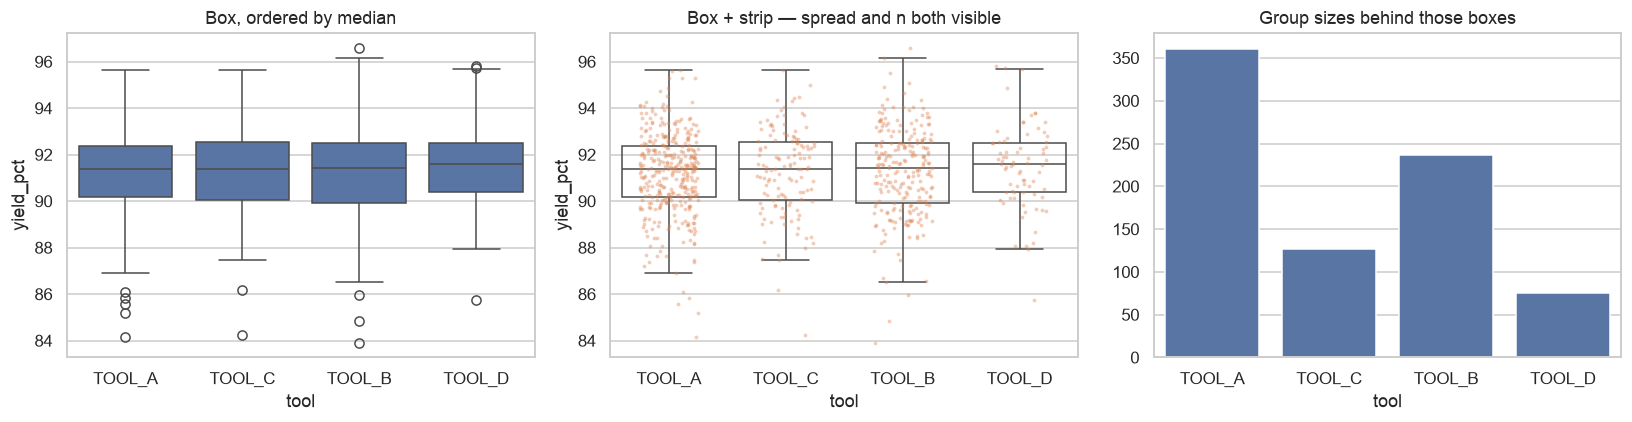

In [10]:
order = df_mix.groupby("tool")["yield_pct"].median().sort_values().index   # order by median

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

sns.boxplot(df_mix, x="tool", y="yield_pct", order=order, ax=axes[0])
axes[0].set_title("Box, ordered by median")

# Points overlaid on a hollow box: summary plus every observation
sns.boxplot(df_mix, x="tool", y="yield_pct", order=order,
            showfliers=False, boxprops={"facecolor": "none"}, ax=axes[1])
sns.stripplot(df_mix, x="tool", y="yield_pct", order=order,
              jitter=.25, size=2.5, alpha=.4, ax=axes[1])
axes[1].set_title("Box + strip — spread and n both visible")

# Annotate group sizes; a box plot alone never tells you these
counts = df_mix["tool"].value_counts().reindex(order)
sns.barplot(x=counts.index, y=counts.values, ax=axes[2])
axes[2].set_title("Group sizes behind those boxes")

plt.tight_layout(); plt.show()

### B7. Bar plot with confidence intervals — group means

**What it shows.** A summary statistic per group (mean by default) with an uncertainty interval.

**How to read it.** The bar is the point estimate; the error bar is the sampling uncertainty of that estimate. Wider intervals mean smaller groups or higher variance.

**Fails when.**

- **The bar chart of means problem.** Two groups with identical means but wildly different distributions produce identical bars. A bar plot is the least informative way to compare distributions — prefer box or violin unless the audience specifically needs a mean.
- **Truncated y-axis.** Starting the axis above zero exaggerates small differences. Bars encode length, so the baseline must be zero. If you need a truncated axis, use a point plot instead — dots encode position, not length.
- **Overlapping CIs are not a hypothesis test.** Non-overlap implies significance, but overlap does *not* imply non-significance. Run the actual test.

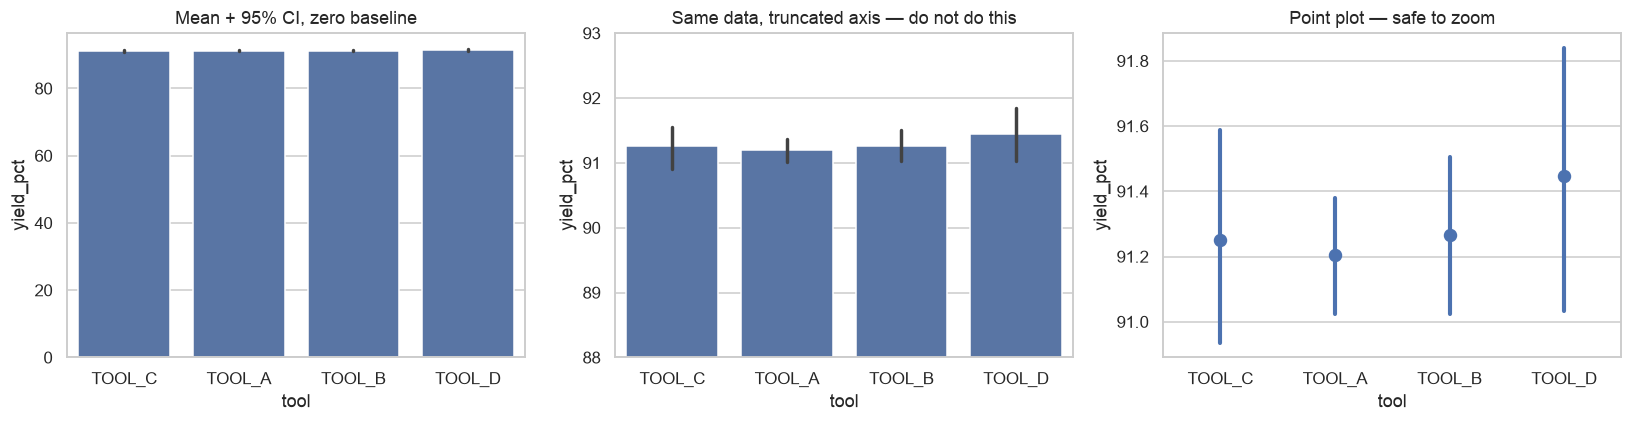

In [11]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# errorbar=('ci', 95) bootstraps a 95% CI of the mean; use ('sd',) for raw spread
sns.barplot(df_mix, x="tool", y="yield_pct", errorbar=("ci", 95), ax=axes[0])
axes[0].set_title("Mean + 95% CI, zero baseline")

axes[1].set_ylim(88, 93)   # deliberately misleading
sns.barplot(df_mix, x="tool", y="yield_pct", errorbar=("ci", 95), ax=axes[1])
axes[1].set_title("Same data, truncated axis — do not do this")

# Point plot: legitimate with a truncated axis because position, not length, is the encoding
sns.pointplot(df_mix, x="tool", y="yield_pct", errorbar=("ci", 95),
              linestyle="none", ax=axes[2])
axes[2].set_title("Point plot — safe to zoom")

plt.tight_layout(); plt.show()

### B8. Overlaid KDE by class — feature separability and drift

**What it shows.** Two uses of the same plot:

1. **Separability** — how much a feature's distribution differs between target classes. Big separation means the feature carries signal on its own.
2. **Drift / split sanity** — whether train and test (or two time periods) are drawn from the same distribution.

**How to read it.** The overlap area is the irreducible confusion from that feature alone. Near-total overlap means the feature is useless in isolation, though it may still matter in interaction with others — do not drop it on this plot alone.

**Fails when.**

- `common_norm=True` (the default when using `hue`) normalises across both classes together, so with an 8% positive rate the minority curve is flattened to near-invisible. **Set `common_norm=False`** to compare shapes rather than volumes.
- Single-feature separability says nothing about multivariate signal. A feature that overlaps completely can still be the most important one in a tree model.

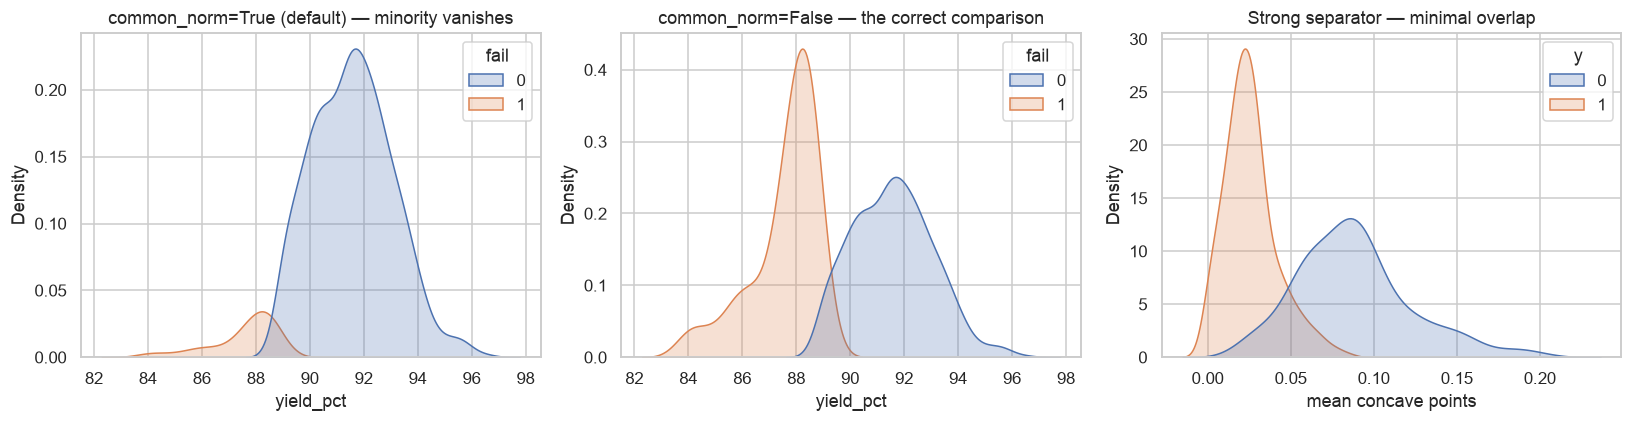

In [12]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

sns.kdeplot(df_mix, x="yield_pct", hue="fail", fill=True, ax=axes[0])
axes[0].set_title("common_norm=True (default) — minority vanishes")

# common_norm=False normalises each class separately: compares SHAPE, not volume
sns.kdeplot(df_mix, x="yield_pct", hue="fail", fill=True, common_norm=False, ax=axes[1])
axes[1].set_title("common_norm=False — the correct comparison")

sns.kdeplot(df_clf, x="mean concave points", hue="y", fill=True,
            common_norm=False, ax=axes[2])
axes[2].set_title("Strong separator — minimal overlap")

plt.tight_layout(); plt.show()

### B9. Grouped count / crosstab heatmap — two categoricals

**What it shows.** How two categorical variables co-occur.

**How to read it.** Choose the normalisation to match the question:

| You want to know | Use |
|---|---|
| Raw volume in each combination | `pd.crosstab(a, b)` |
| Rate of b *within* each level of a | `pd.crosstab(a, b, normalize='index')` |
| Share of the whole table | `pd.crosstab(a, b, normalize='all')` |

Empty or near-empty cells are the actionable finding — that combination either never happens or is being filtered upstream, and any model will extrapolate blindly there.

**Fails when.**

- Raw counts are dominated by the most common level, so genuine rate differences in small categories are invisible. Normalise by row.
- With many levels on both axes the annotations become unreadable — drop `annot`, or aggregate rare levels first.

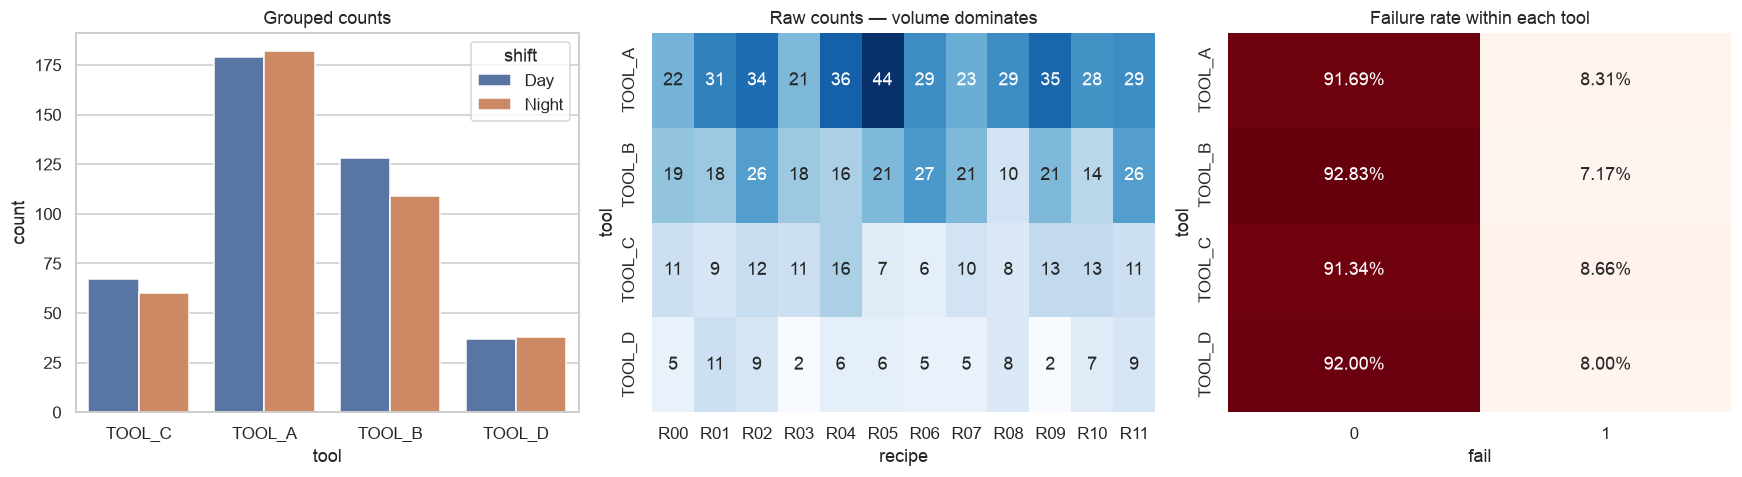

In [13]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))

sns.countplot(df_mix, x="tool", hue="shift", ax=axes[0])
axes[0].set_title("Grouped counts")

ct = pd.crosstab(df_mix["tool"], df_mix["recipe"])
sns.heatmap(ct, annot=True, fmt="d", cmap="Blues", cbar=False, ax=axes[1])
axes[1].set_title("Raw counts — volume dominates")

# normalize='index' => each row sums to 1, so rows are comparable regardless of size
ct_rate = pd.crosstab(df_mix["tool"], df_mix["fail"], normalize="index")
sns.heatmap(ct_rate, annot=True, fmt=".2%", cmap="Reds", cbar=False, ax=axes[2])
axes[2].set_title("Failure rate within each tool")

plt.tight_layout(); plt.show()

### B10. Pair plot — every pair at once

**What it shows.** A scatter matrix of all numeric columns, with distributions on the diagonal.

**How to read it.** Scan for three things: pairs forming a tight diagonal line (redundant features), panels where `hue` classes separate cleanly (strong single predictors), and curved rather than straight relationships.

**Fails when.**

- Cost is quadratic in columns. At 30 features that is 900 panels — unusable and slow. Cap it at 6–10 columns, chosen by correlation with the target or by importance.
- `corner=True` halves the render time and removes the redundant mirror-image panels.
- With more than a few thousand rows each panel saturates. Subsample first.

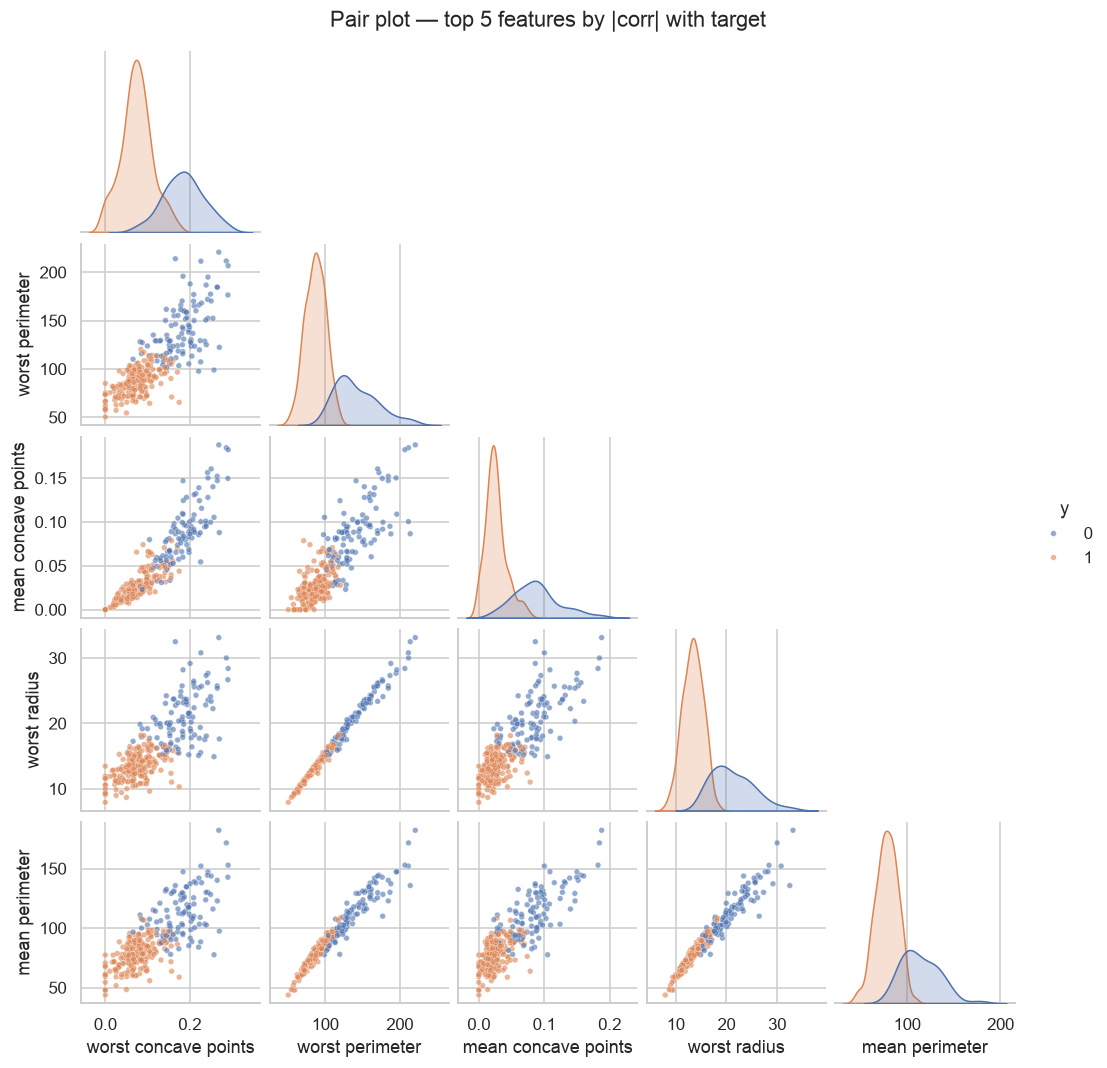

In [14]:
# Pick the 5 features most correlated with the target rather than the first 5 columns
top5 = (df_clf.corr(numeric_only=True)["y"].abs()
        .drop("y").sort_values(ascending=False).head(5).index.tolist())

g = sns.pairplot(df_clf[top5 + ["y"]].sample(300, random_state=42),
                 hue="y", corner=True, diag_kind="kde",
                 plot_kws={"s": 14, "alpha": .6}, height=1.9)
g.figure.suptitle("Pair plot — top 5 features by |corr| with target", y=1.02)
plt.show()

### B11. Correlation heatmap / cluster map — the association matrix

**What it shows.** Pairwise linear association between every numeric column.

**How to read it.** Two separate readings:

- **The target row/column** — a first-pass shortlist of predictive features. Not an importance ranking.
- **The feature-by-feature block** — redundancy. Deep red or deep blue off-diagonal pairs (|r| > 0.8) are carrying the same information.

Always fix `vmin=-1, vmax=1, center=0` with a diverging colormap. Without it seaborn autoscales the colour range and a maximum correlation of 0.3 renders as vivid red, which is badly misleading.

**Fails when.**

- Pearson only detects **linear** association. A perfect parabola gives r near 0. Cross-check with Spearman (C3).
- **Correlation with the target is not feature importance.** A feature can be uncorrelated alone and vital in interaction.
- **High pairwise correlation is not the same as multicollinearity.** Three features can each be weakly correlated pairwise yet be perfectly collinear as a set. Only VIF (C4) catches that.
- A raw heatmap of 30+ features is unreadable. Use `clustermap` to reorder into blocks.

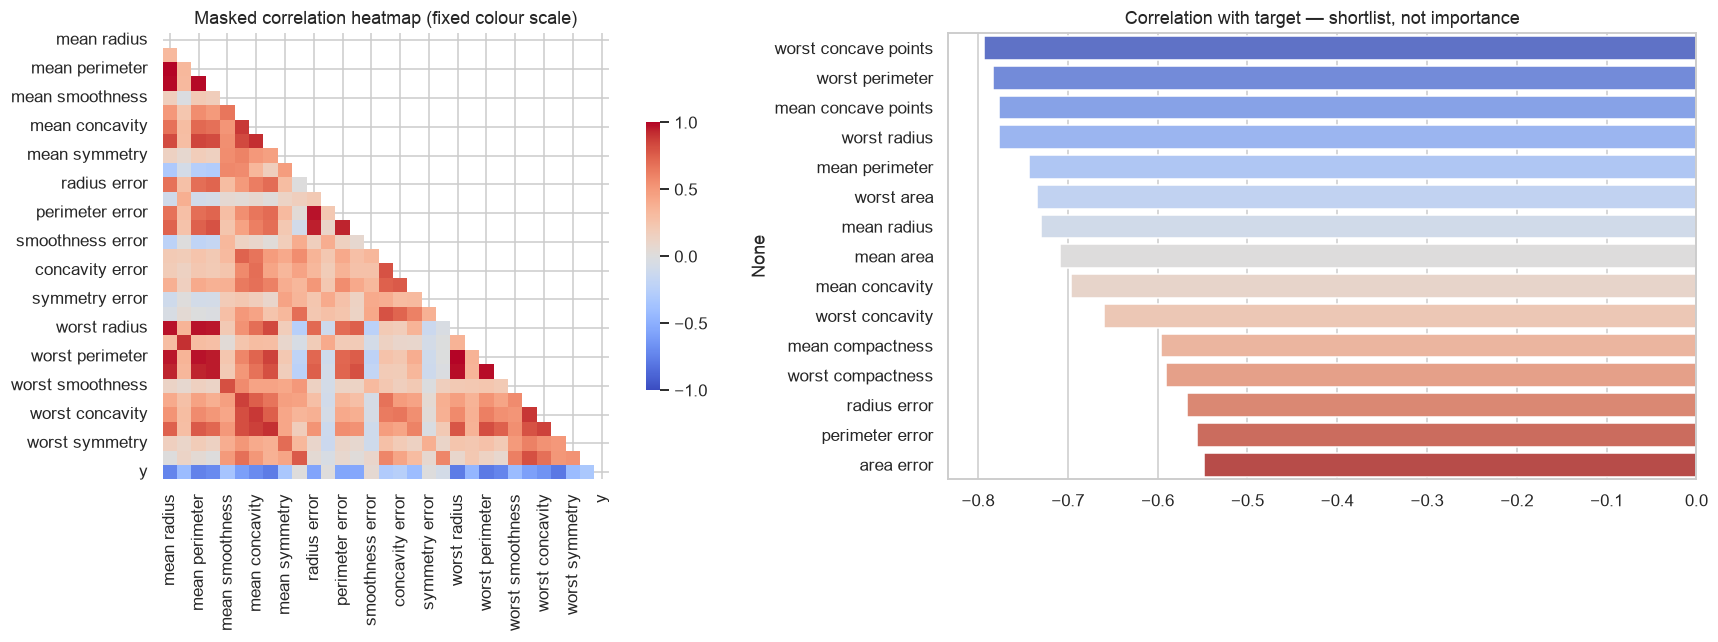

In [15]:
corr = df_clf.corr(numeric_only=True)
mask = np.triu(np.ones_like(corr, dtype=bool))   # hide the redundant upper triangle

fig, axes = plt.subplots(1, 2, figsize=(17, 6))

sns.heatmap(corr, mask=mask, cmap="coolwarm", center=0, vmin=-1, vmax=1,
            square=True, cbar_kws={"shrink": .6}, ax=axes[0])
axes[0].set_title("Masked correlation heatmap (fixed colour scale)")

# Shortlist by absolute correlation with the target
tgt = corr["y"].drop("y").sort_values(key=abs, ascending=False).head(15)
sns.barplot(x=tgt.values, y=tgt.index, hue=tgt.index, palette="coolwarm",
            legend=False, ax=axes[1])
axes[1].axvline(0, c="k", lw=.8)
axes[1].set_title("Correlation with target — shortlist, not importance")

plt.tight_layout(); plt.show()

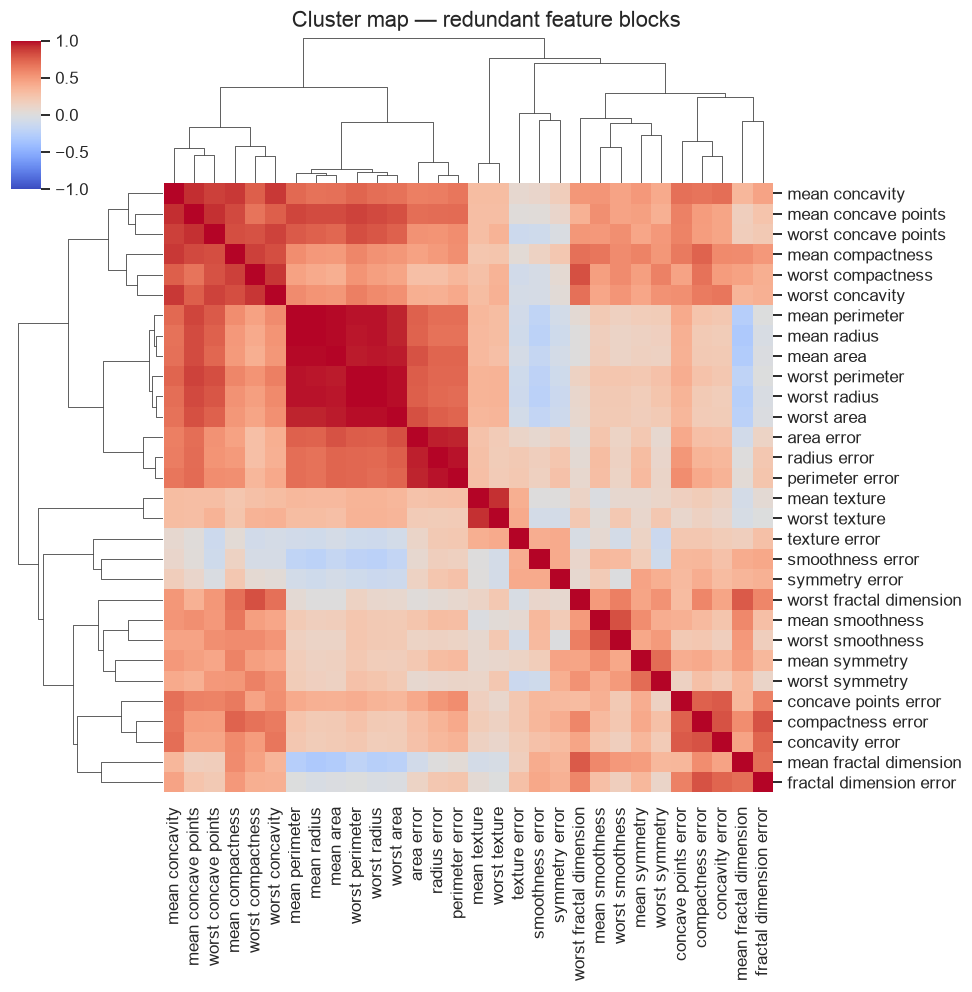

             level_0          level_1         r
60    mean perimeter      mean radius  0.997855
680  worst perimeter     worst radius  0.993708
90         mean area      mean radius  0.987357
92         mean area   mean perimeter  0.986507
710       worst area     worst radius  0.984015
712       worst area  worst perimeter  0.977578
370  perimeter error     radius error  0.972794
662  worst perimeter   mean perimeter  0.970387
600     worst radius      mean radius  0.969539
602     worst radius   mean perimeter  0.969476


In [16]:
# clustermap reorders rows/columns by hierarchical clustering, so mutually
# correlated features form visible blocks. It creates its own figure.
g = sns.clustermap(df_clf.drop(columns="y").corr(), cmap="coolwarm", center=0,
                   vmin=-1, vmax=1, figsize=(9, 9), cbar_pos=(.02, .82, .03, .15))
g.figure.suptitle("Cluster map — redundant feature blocks", y=1.0)
plt.show()

# Explicit list of redundant pairs, so you are not squinting at colours
pairs = (corr.drop(columns="y").drop(index="y")
         .where(~np.triu(np.ones(corr.shape[0] - 1, dtype=bool)))
         .stack().rename("r").reset_index())
print(pairs.loc[pairs["r"].abs() > .9].sort_values("r", key=abs, ascending=False).head(10))

### B12. Line plot / rolling mean — ordered and time series data

**What it shows.** How a value evolves along an ordered axis.

**How to read it.** Separate four components: **trend** (long-run direction), **seasonality** (repeating cycle), **level shifts** (abrupt steps — usually a process or system change), and **variance changes** (the band widening or narrowing).

A step change in the mean is the finding that matters most operationally. A widening band without a mean shift means the process is getting less stable while its average stays put.

**Fails when.**

- The x-axis is not sorted. A line plot on unsorted data produces a meaningless zigzag. Always `sort_values` first.
- A rolling mean **lags** the true signal by roughly half the window and smooths away the step changes you were looking for. Plot raw and smoothed together, never smoothed alone.
- Aggregating to daily or weekly means hides within-period variance. Add a band showing the spread.

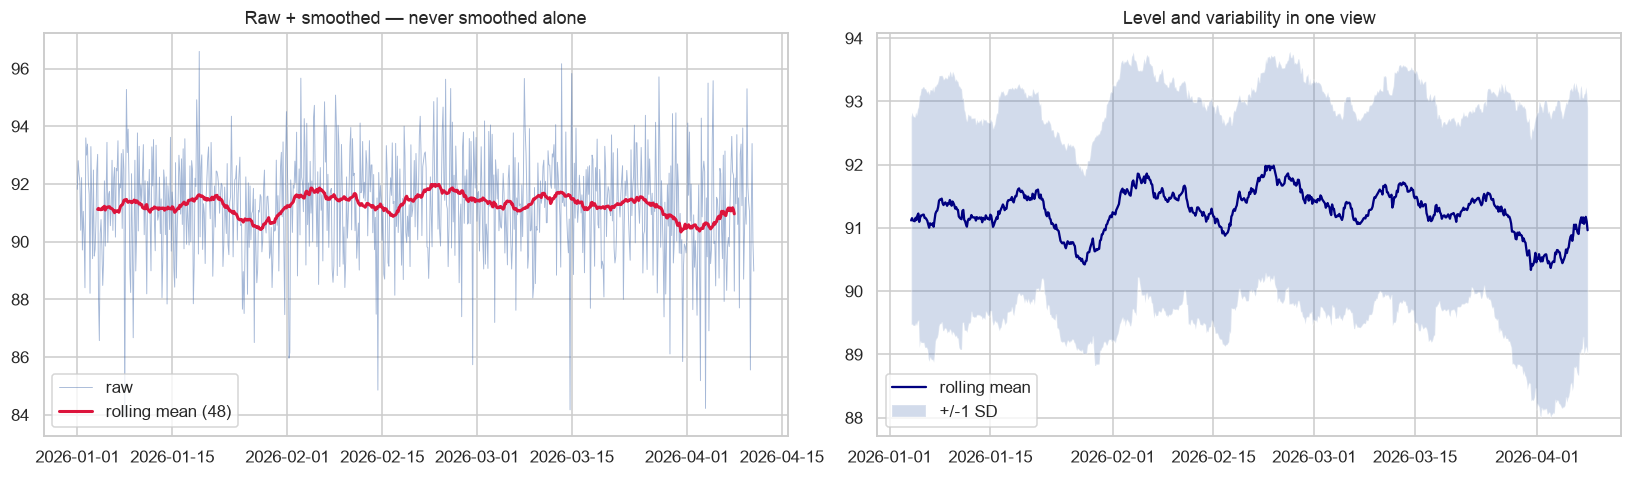

In [17]:
s = df_mix.sort_values("ts").set_index("ts")["yield_pct"]

fig, axes = plt.subplots(1, 2, figsize=(15, 4.5))

axes[0].plot(s.index, s.values, lw=.6, alpha=.5, label="raw")
axes[0].plot(s.index, s.rolling(48, center=True).mean(), lw=2, c="crimson",
             label="rolling mean (48)")   # center=True removes the half-window lag
axes[0].legend(); axes[0].set_title("Raw + smoothed — never smoothed alone")

# Rolling mean with a +/-1 SD band: shows level AND stability together
roll_m = s.rolling(48, center=True).mean()
roll_s = s.rolling(48, center=True).std()
axes[1].plot(s.index, roll_m, c="navy", label="rolling mean")
axes[1].fill_between(s.index, roll_m - roll_s, roll_m + roll_s, alpha=.25, label="+/-1 SD")
axes[1].legend(); axes[1].set_title("Level and variability in one view")

plt.tight_layout(); plt.show()

### B13. Missingness plots — matrix, bar, and null correlation

**What it shows.** Where data is absent, and whether the absence follows a pattern.

**How to read it.** The pattern determines the treatment:

| Pattern | Name | Treatment |
|---|---|---|
| Gaps scattered randomly | MCAR / MAR | Median or model-based imputation is safe |
| Gaps aligned in horizontal bands | Whole rows failed to record | Consider dropping rows, or check for a logging outage |
| Gaps confined to one category or time range | Structured / MNAR | The missingness itself is a signal — add an indicator column |
| Two columns missing together | Shared upstream source | Treat as one unit; imputing them independently invents correlation |

**Fails when.**

- A missingness matrix on an unsorted frame can hide a block pattern that appears immediately after sorting by the suspected driver.
- Deleting rows with missing values silently changes the class balance and the population you are modelling. Check the positive rate before and after.
- Imputing with the median without an indicator flag throws away real information whenever the data is MNAR.

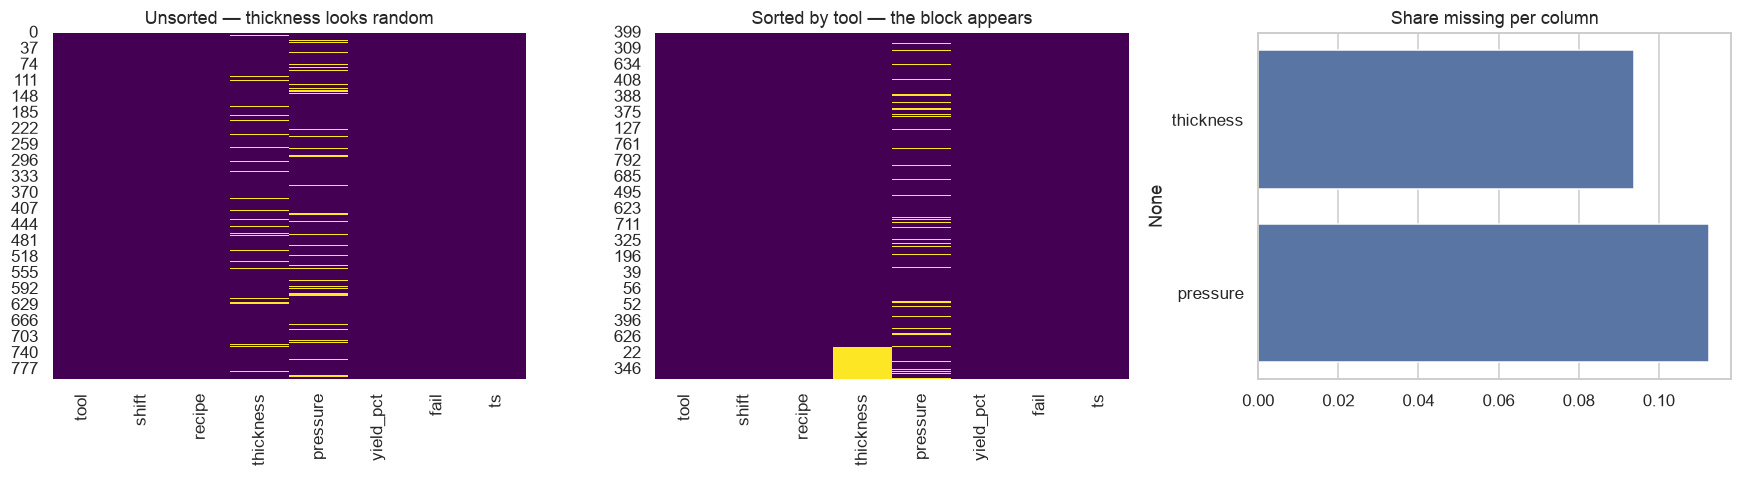

In [18]:
work = df_mix.copy()

fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))

# Missingness matrix — pale cells are nulls
sns.heatmap(work.isna(), cbar=False, cmap="viridis", ax=axes[0])
axes[0].set_title("Unsorted — thickness looks random")

# Sorting by the suspected driver makes structured missingness obvious
sns.heatmap(work.sort_values("tool").isna(), cbar=False, cmap="viridis", ax=axes[1])
axes[1].set_title("Sorted by tool — the block appears")

miss = work.isna().mean().sort_values()
miss = miss[miss > 0]
sns.barplot(x=miss.values, y=miss.index, ax=axes[2])
axes[2].set_title("Share missing per column")

plt.tight_layout(); plt.show()

In [19]:
# Do columns go missing TOGETHER? Correlate the null indicator flags.
null_flags = df_mix.isna().astype(int)
null_flags = null_flags.loc[:, null_flags.sum() > 0]
print("Null-flag correlation:\n", null_flags.corr().round(2), "\n")

# Does dropping nulls change the population you are modelling?
print(f"positive rate, all rows : {df_mix['fail'].mean():.3f}")
print(f"positive rate, dropna   : {df_mix.dropna()['fail'].mean():.3f}")

# Preserve the information before imputing
df_mix["thickness_missing"] = df_mix["thickness"].isna().astype(int)

Null-flag correlation:
            thickness  pressure
thickness       1.00     -0.01
pressure       -0.01      1.00 

positive rate, all rows : 0.080
positive rate, dropna   : 0.082


## Part C — The Statistical Layer

A plot suggests something. This section is what you run to confirm it, and what the number actually licenses you to say.

### C1. Skew, kurtosis, and transformations

**Quantities.**

| Statistic | Value | Reading |
|---|---|---|
| Skew | ~0 | Symmetric |
| Skew | > +1 | Strong right skew (long tail toward high values) |
| Skew | < -1 | Strong left skew |
| Excess kurtosis | ~0 | Normal-like tails |
| Excess kurtosis | > 3 | Heavy tails — outliers more common than a normal predicts |

`scipy.stats.kurtosis` returns **excess** kurtosis by default (normal = 0), not raw kurtosis (normal = 3). Getting this backwards is a common misreading.

**Which transform.**

| Data | Transform |
|---|---|
| Strictly positive, right-skewed | `np.log(x)` |
| Contains zeros, right-skewed | `np.log1p(x)` |
| Counts | `np.sqrt(x)` |
| Contains negatives, or you want it chosen automatically | `PowerTransformer(method="yeo-johnson")` |
| Positive only, automatic | `PowerTransformer(method="box-cox")` |

**When it matters.** Skew affects linear models, regularised linear models, and anything distance-based (KNN, SVM, k-means, PCA). **Trees are invariant to any monotone transform** — a log transform cannot change which side of a split a point falls on, so it changes nothing for Random Forest or XGBoost. Do not transform features for a tree model and expect a different result.

**Fails when.** Fitting the transformer on the full dataset before splitting leaks test information into training. Put `PowerTransformer` inside a `Pipeline` so it is fitted on training folds only.

raw   skew=+1.38  excess kurtosis=+2.75
log   skew=+0.07
yeo-j skew=+0.01  (lambda=-0.198)


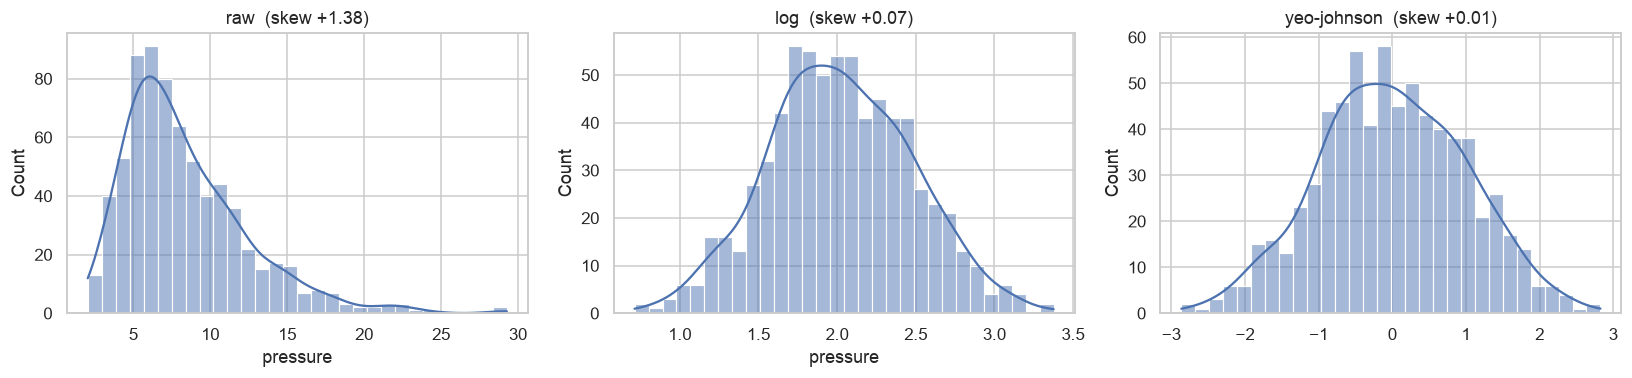

In [20]:
from sklearn.preprocessing import PowerTransformer

x = df_mix["pressure"].dropna()

print(f"raw   skew={stats.skew(x):+.2f}  excess kurtosis={stats.kurtosis(x):+.2f}")
print(f"log   skew={stats.skew(np.log(x)):+.2f}")

# Yeo-Johnson picks the exponent by maximum likelihood; handles zero and negative values
pt = PowerTransformer(method="yeo-johnson")
yj = pt.fit_transform(x.to_frame()).ravel()
print(f"yeo-j skew={stats.skew(yj):+.2f}  (lambda={pt.lambdas_[0]:.3f})")

fig, axes = plt.subplots(1, 3, figsize=(15, 3.6))
for ax, data, name in zip(axes, [x, np.log(x), yj], ["raw", "log", "yeo-johnson"]):
    sns.histplot(data, bins=30, kde=True, ax=ax)
    ax.set_title(f"{name}  (skew {stats.skew(data):+.2f})")
plt.tight_layout(); plt.show()

### C2. Normality — QQ plots and tests

**The misconception to kill first.** OLS does **not** assume your features are normally distributed. It does not assume the target is normally distributed either. The normality assumption is on the **residuals**, and even then it only affects the validity of p-values and confidence intervals, not the coefficient estimates themselves. Check normality on residuals, after fitting — not on raw features, before.

**Reading a QQ plot.** Sample quantiles on the y-axis, theoretical normal quantiles on the x-axis.

| Shape | Meaning |
|---|---|
| Points on the diagonal | Normal |
| Both ends bending above the line at the right, below at the left | Heavy tails |
| S-curve | Skew |
| Staircase steps | Discrete or heavily rounded data |

**Tests.**

| Test | Use |
|---|---|
| Shapiro-Wilk | Best power at n < 5,000; scipy warns above that |
| D'Agostino-Pearson | Combines skew and kurtosis; scales to larger n |
| Anderson-Darling | More sensitive in the tails |

**Fails when.** At large n every normality test rejects, because no real data is exactly normal and the test's power grows with sample size. At n = 50,000 a p-value of 0.001 may correspond to a deviation too small to matter. **The QQ plot is the decision-maker; the test is supporting evidence.**

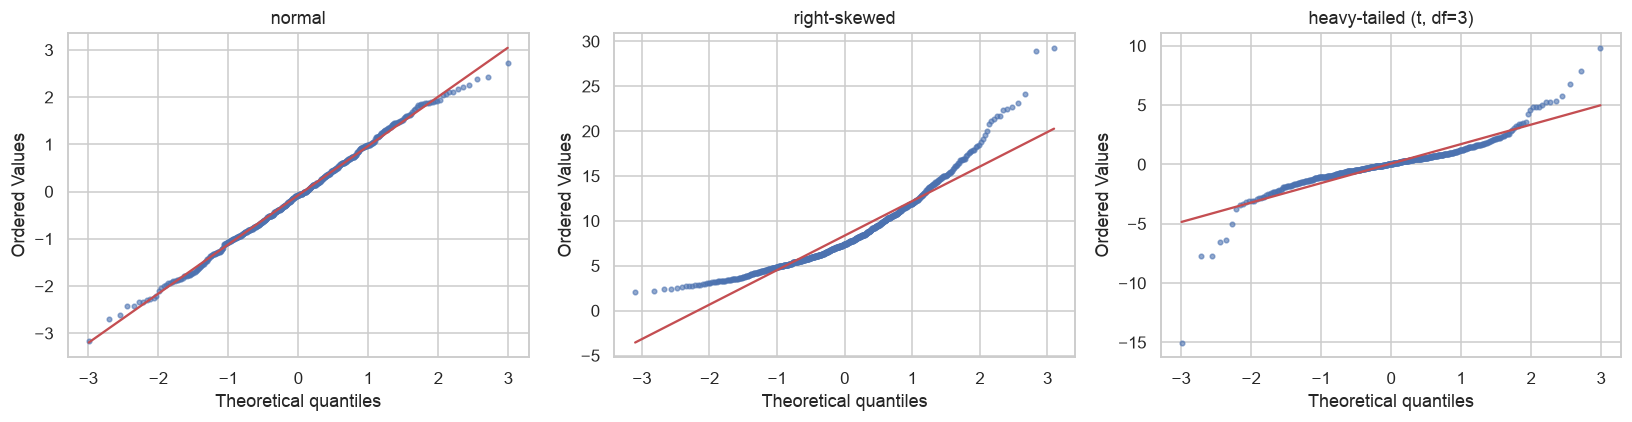

normal   shapiro p=2.68e-01   dagostino p=5.76e-01
skewed   shapiro p=9.58e-21   dagostino p=1.50e-41


In [21]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for ax, data, name in zip(
        axes,
        [RNG.normal(0, 1, 500), df_mix["pressure"].dropna().values, RNG.standard_t(3, 500)],
        ["normal", "right-skewed", "heavy-tailed (t, df=3)"]):
    stats.probplot(data, dist="norm", plot=ax)   # QQ plot against the normal
    ax.set_title(name)
    ax.get_lines()[0].set(markersize=3, alpha=.6)

plt.tight_layout(); plt.show()

for name, data in [("normal", RNG.normal(0, 1, 500)),
                   ("skewed", df_mix["pressure"].dropna().values)]:
    W, p_sw = stats.shapiro(data)             # n < 5000
    K, p_dp = stats.normaltest(data)          # D'Agostino-Pearson
    print(f"{name:8s} shapiro p={p_sw:.2e}   dagostino p={p_dp:.2e}")

### C3. Correlation — Pearson, Spearman, Kendall

| Coefficient | Measures | Use when |
|---|---|---|
| Pearson | Linear association | Both variables roughly continuous, no extreme outliers |
| Spearman | Monotone association (rank-based) | Non-linear but consistently increasing/decreasing, or ordinal data, or outliers present |
| Kendall | Concordance of pairs | Small samples, many tied values |

**The diagnostic move.** Compute both Pearson and Spearman. If **Spearman is much larger than Pearson**, the relationship is monotone but curved — a transform or a spline will help a linear model. If **Pearson is much larger than Spearman**, a few extreme points are driving the linear correlation.

**Fails when.**

- Pearson near zero does **not** mean independence. A symmetric parabola has r ~ 0 with a perfect deterministic relationship.
- Correlation is not causation, and correlation with the target is not importance.
- One outlier can move Pearson from 0.1 to 0.8 in a small sample.

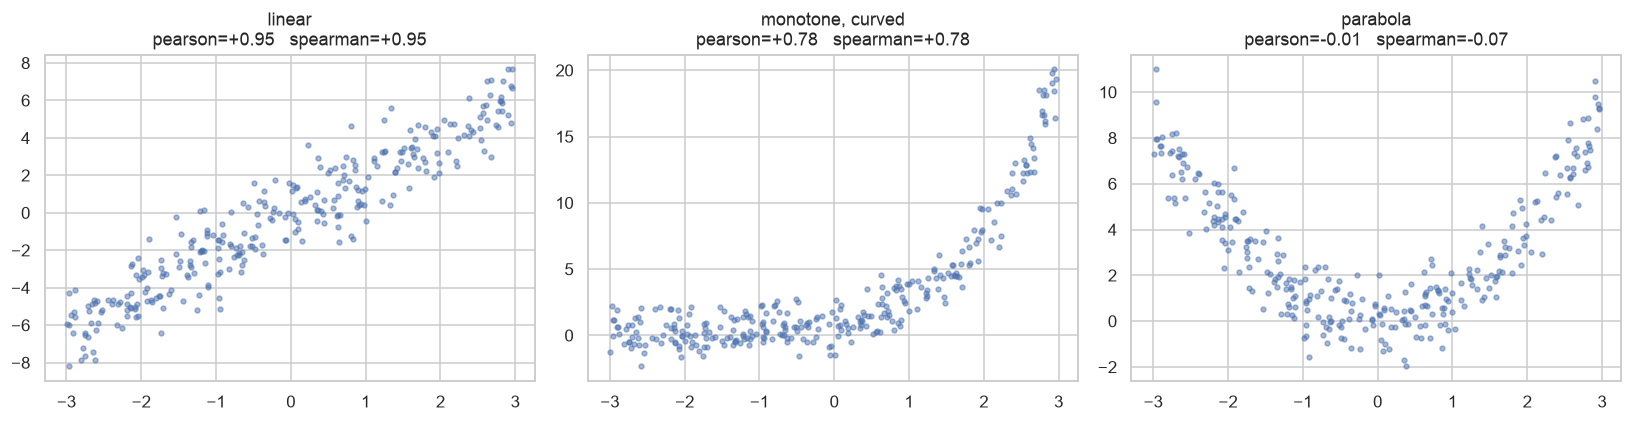

In [22]:
u = RNG.uniform(-3, 3, 300)

cases = {
    "linear":            (u, 2 * u + RNG.normal(0, 1.2, 300)),
    "monotone, curved":  (u, np.exp(u) + RNG.normal(0, 1, 300)),
    "parabola":          (u, u ** 2 + RNG.normal(0, 1, 300)),
}

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, (name, (a, b)) in zip(axes, cases.items()):
    r_p = stats.pearsonr(a, b).statistic
    r_s = stats.spearmanr(a, b).statistic
    ax.scatter(a, b, s=10, alpha=.5)
    ax.set_title(f"{name}\npearson={r_p:+.2f}   spearman={r_s:+.2f}")
plt.tight_layout(); plt.show()

### C4. Multicollinearity and VIF

**What VIF is.** For feature $j$, regress $x_j$ on **all the other features** and take the $R^2$ of that auxiliary regression:

$$\text{VIF}_j = \frac{1}{1 - R^2_j}$$

That $R^2_j$ is not the model's $R^2$. It measures how well the *other features* predict $x_j$. VIF = 5 means 80% of $x_j$ is explained by the rest; VIF = 10 means 90%.

| VIF | Reading |
|---|---|
| ~1 | Independent of the other features |
| 1–5 | Moderate, usually acceptable |
| 5–10 | Concerning |
| > 10 | Severe — coefficients are unstable |

**What multicollinearity actually breaks.** It inflates coefficient standard errors, makes signs flip when you add or remove a row, and destroys the interpretability of individual coefficients. It does **not** meaningfully hurt predictive accuracy, and it is **irrelevant to tree models** — Random Forest and XGBoost split on one feature at a time and are unaffected.

**Fixes.** Drop one of each redundant pair, combine them into a ratio or difference, apply PCA, or switch to Ridge (which is designed for exactly this).

**Fails when.** Pairwise correlation misses it. Three features each pairwise-correlated at only 0.5 can be perfectly collinear as a set. VIF is the only check that catches multi-way collinearity.

mean radius        413.2
mean perimeter     412.3
mean area           40.5
mean smoothness      1.8
mean symmetry        1.7
mean texture         1.2
dtype: float64 

max pairwise |corr|: 0.72
max VIF            : inf


/opt/anaconda3/envs/dsprint/lib/python3.11/site-packages/statsmodels/stats/outliers_influence.py:197: RuntimeWarning: divide by zero encountered in scalar divide
  vif = 1. / (1. - r_squared_i)


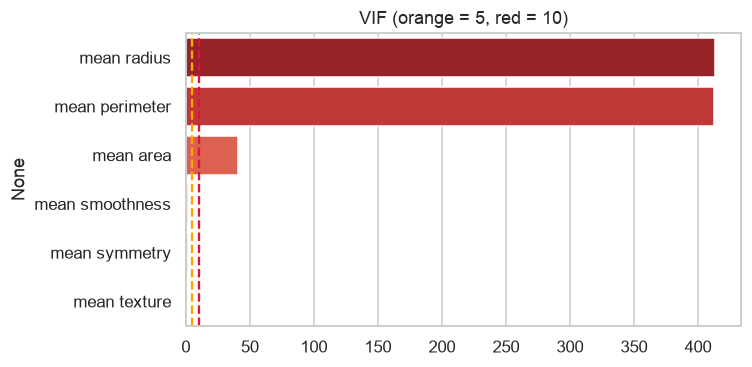

In [23]:
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.tools.tools import add_constant

def vif_table(X):
    # add_constant is required: without an intercept column the VIFs come out inflated
    Xc = add_constant(X.astype(float), has_constant="add")
    vals = [variance_inflation_factor(Xc.values, i) for i in range(1, Xc.shape[1])]
    return pd.Series(vals, index=X.columns).sort_values(ascending=False)

subset = ["mean radius", "mean perimeter", "mean area",
          "mean texture", "mean smoothness", "mean symmetry"]
v = vif_table(df_clf[subset])
print(v.round(1), "\n")

# Demonstration: pairwise correlation misses multi-way collinearity
demo = pd.DataFrame({"a": RNG.normal(size=400), "b": RNG.normal(size=400)})
demo["c"] = demo["a"] + demo["b"]              # exactly collinear as a SET
print("max pairwise |corr|:", demo.corr().abs().where(~np.eye(3, dtype=bool)).max().max().round(2))
print("max VIF            :", vif_table(demo).max().round(1))

fig, ax = plt.subplots(figsize=(7, 3.5))
sns.barplot(x=v.values, y=v.index, hue=v.index, palette="Reds_r", legend=False, ax=ax)
ax.axvline(5, ls="--", c="orange"); ax.axvline(10, ls="--", c="crimson")
ax.set_title("VIF (orange = 5, red = 10)")
plt.tight_layout(); plt.show()

### C5. Outliers — detection and model sensitivity

**Three detection rules.**

| Method | Rule | Use when |
|---|---|---|
| Z-score | `|z| > 3` | Roughly normal data |
| IQR fence | Outside `Q1 - 1.5*IQR` to `Q3 + 1.5*IQR` | Skewed data; no distributional assumption |
| Modified z (MAD) | `0.6745 * (x - median) / MAD`, flag `> 3.5` | Data already contaminated — the mean and SD used by plain z-score are themselves distorted by the outliers |

The modified z-score is the robust choice, because plain z-score uses statistics that the outliers have already corrupted. This is called masking.

**Model sensitivity.**

| Model | Sensitive to outliers? | Why |
|---|---|---|
| Linear regression (OLS) | Very | Squared loss gives an extreme point quadratic leverage |
| Ridge / Lasso | Very | Same squared loss |
| KNN, SVM (RBF), k-means | Very | Distance-based |
| PCA | Very | Maximises variance, which outliers dominate |
| Decision tree, Random Forest | Barely | Splits on rank order, not magnitude |
| XGBoost | Somewhat | Squared-error objective by default; use a robust objective if severe |

**Fails when.** Removing outliers because they are statistically unusual, when they are the event you are trying to predict. In any rare-event problem the positives *are* the outliers — deleting them destroys the target. Always check the class balance of the rows you are about to remove.

z>3                7
IQR fence         15
modified z>3.5     5
dtype: int64 

z>3              flags    7 rows, 100.0% of them are positives
IQR fence        flags   15 rows, 86.7% of them are positives
modified z>3.5   flags    5 rows, 100.0% of them are positives


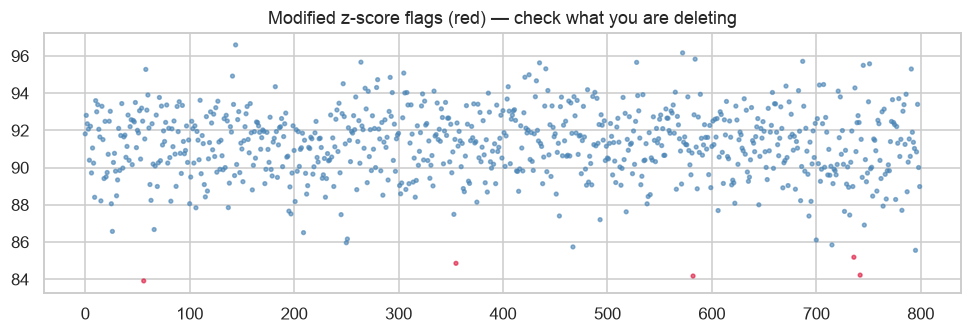

In [24]:
x = df_mix["yield_pct"].values

z      = np.abs(stats.zscore(x)) > 3
q1, q3 = np.percentile(x, [25, 75]); iqr = q3 - q1
fence  = (x < q1 - 1.5 * iqr) | (x > q3 + 1.5 * iqr)
mad    = np.median(np.abs(x - np.median(x)))
modz   = np.abs(0.6745 * (x - np.median(x)) / mad) > 3.5

flags = pd.DataFrame({"z>3": z, "IQR fence": fence, "modified z>3.5": modz})
print(flags.sum(), "\n")

# The critical check before deleting anything
for name in flags.columns:
    print(f"{name:16s} flags {flags[name].sum():4d} rows, "
          f"{df_mix.loc[flags[name].values, 'fail'].mean():.1%} of them are positives")

fig, ax = plt.subplots(figsize=(9, 3.2))
ax.scatter(range(len(x)), x, s=6, c=np.where(modz, "crimson", "steelblue"), alpha=.6)
ax.set_title("Modified z-score flags (red) — check what you are deleting")
plt.tight_layout(); plt.show()

### C6. Class imbalance — what it changes

**The accuracy paradox.** At an 8% positive rate, a model that predicts "negative" for every row scores 92% accuracy and is worthless. The majority-class rate is the floor, not a good score.

**Baselines you must state alongside any metric.**

| Metric | Baseline for a useless model |
|---|---|
| Accuracy | The majority-class rate |
| ROC-AUC | 0.50 |
| PR-AUC / average precision | The positive prevalence (0.08 here) |

**Metric choice.**

| Situation | Metric |
|---|---|
| Balanced classes | Accuracy, ROC-AUC |
| Imbalanced, both error types matter | F1, balanced accuracy, Matthews correlation |
| Imbalanced, positives are the point | PR-AUC / average precision, recall at a fixed precision |
| Cost of FP and FN differ | Expected cost at a tuned threshold |

**Handling options, in order of what to try first.**

1. **Tune the decision threshold** — free, no retraining, usually the biggest single win. `predict()` hard-codes 0.5, which is almost never optimal under imbalance.
2. **`class_weight="balanced"`** (sklearn) or **`scale_pos_weight`** (XGBoost) — reweights the loss, no data fabrication.
3. **Resampling (SMOTE, undersampling)** — last resort. Must sit inside the `Pipeline` so it applies to training folds only. Applying SMOTE before cross-validation leaks synthetic points into validation folds and inflates every score.

**Fails when.** Comparing PR-AUC across datasets with different prevalence. The PR baseline moves with prevalence, so a PR-AUC of 0.4 at 5% positives is far better than 0.4 at 40% positives.

In [25]:
from sklearn.metrics import average_precision_score, roc_auc_score

prev = df_mix["fail"].mean()
print(f"positive prevalence     : {prev:.3f}")
print(f"majority-class accuracy : {1 - prev:.3f}   <- the floor to beat")
print(f"ROC-AUC baseline        : 0.500")
print(f"PR-AUC baseline         : {prev:.3f}\n")

# Same ranking quality, two prevalences: ROC is unchanged, PR is not
for p in [0.50, 0.08]:
    m = int(2000 * p)
    yv = np.r_[np.ones(m), np.zeros(2000 - m)]
    sc = np.r_[RNG.normal(1.0, 1, m), RNG.normal(0, 1, 2000 - m)]
    print(f"prevalence {p:.2f} -> ROC-AUC {roc_auc_score(yv, sc):.3f} | "
          f"PR-AUC {average_precision_score(yv, sc):.3f}")

positive prevalence     : 0.080
majority-class accuracy : 0.920   <- the floor to beat
ROC-AUC baseline        : 0.500
PR-AUC baseline         : 0.080

prevalence 0.50 -> ROC-AUC 0.769 | PR-AUC 0.761
prevalence 0.08 -> ROC-AUC 0.786 | PR-AUC 0.268


### C7. Scaling — which models need it

| Model | Scaling required | Reason |
|---|---|---|
| KNN, k-means, DBSCAN | **Yes** | Distance is dominated by the largest-range feature |
| SVM (any kernel) | **Yes** | Kernel is distance-based |
| PCA | **Yes** | Maximises variance; a large-variance feature captures PC1 by unit choice alone |
| Ridge, Lasso, ElasticNet | **Yes** | The penalty is applied equally to all coefficients, so unscaled features are penalised unequally |
| Logistic / linear regression, unregularised | Optional | Coefficients simply rescale; helps gradient descent converge faster |
| Neural networks | **Yes** | Gradient stability |
| Decision tree, Random Forest, XGBoost | **No** | Splits are on rank order; a monotone rescaling changes nothing |

**Which scaler.**

| Scaler | Effect | Use when |
|---|---|---|
| `StandardScaler` | Mean 0, SD 1 | Roughly symmetric data |
| `MinMaxScaler` | Squeezed to [0, 1] | Bounded inputs needed; **very** outlier-sensitive |
| `RobustScaler` | Centred on median, scaled by IQR | Outliers present |

**Sequencing.** Impute before scaling. `StandardScaler` propagates NaN, and if you scale first then impute with the median, you are imputing on a scale computed from incomplete data. Inside a `Pipeline` the order is `SimpleImputer` then a scaler.

**Fails when.** Fitting the scaler on the full dataset before splitting. The test set's mean and SD leak into training. `Pipeline` prevents this because `fit` runs only on training folds.

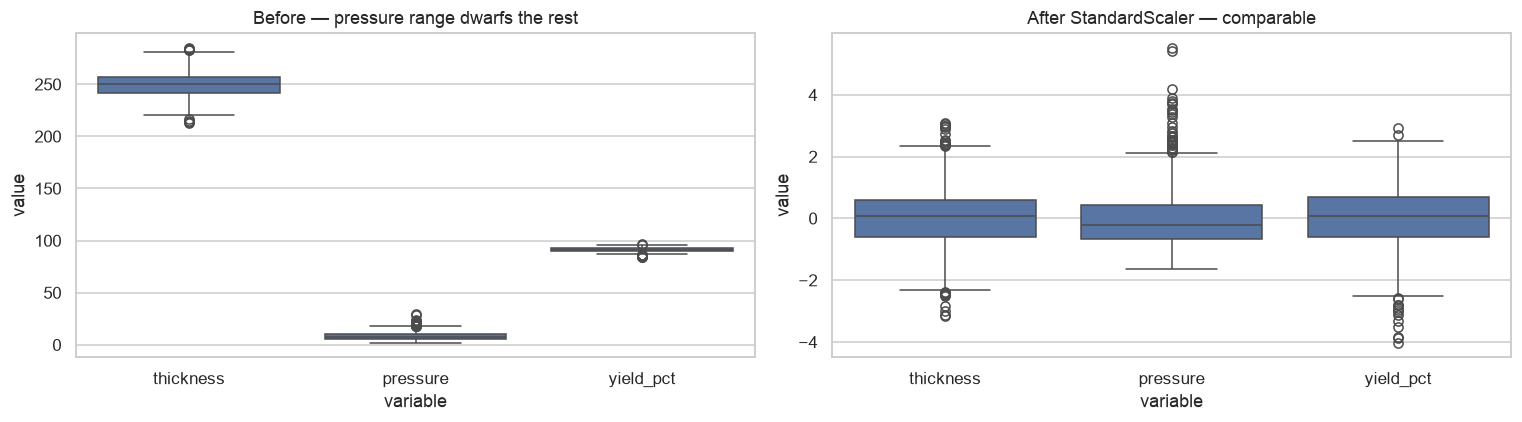

StandardScaler   bulk SD after scaling: 0.339
MinMaxScaler     bulk SD after scaling: 0.024
RobustScaler     bulk SD after scaling: 0.774


In [26]:
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, MinMaxScaler, RobustScaler

# Correct order: impute -> scale. Wrapped in a Pipeline so both are fitted on
# training folds only, which is what prevents leakage during cross-validation.
prep = Pipeline([
    ("impute", SimpleImputer(strategy="median")),
    ("scale",  StandardScaler()),
])

num = df_mix[["thickness", "pressure", "yield_pct"]]
scaled = pd.DataFrame(prep.fit_transform(num), columns=num.columns)

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
sns.boxplot(num.melt(), x="variable", y="value", ax=axes[0])
axes[0].set_title("Before — pressure range dwarfs the rest")
sns.boxplot(scaled.melt(), x="variable", y="value", ax=axes[1])
axes[1].set_title("After StandardScaler — comparable")
plt.tight_layout(); plt.show()

# Outlier sensitivity of the three scalers
spiked = np.r_[RNG.normal(0, 1, 200), [40.0]]        # one extreme value
for sc in [StandardScaler(), MinMaxScaler(), RobustScaler()]:
    out = sc.fit_transform(spiked.reshape(-1, 1)).ravel()
    print(f"{type(sc).__name__:16s} bulk SD after scaling: {out[:200].std():.3f}")

### C8. The tests behind group-comparison plots

A box plot showing a median gap is a hypothesis, not a finding. This is what confirms it.

| Comparison | Parametric test | Non-parametric alternative | Effect size |
|---|---|---|---|
| Two group means | Welch's t-test | Mann-Whitney U | Cohen's d |
| 3+ group means | One-way ANOVA | Kruskal-Wallis | Eta squared |
| Two categoricals | Chi-square | Fisher exact (small cells) | Cramer's V |
| Paired measurements | Paired t-test | Wilcoxon signed-rank | Cohen's d |

**Use Welch's t-test by default** (`equal_var=False`). It does not assume equal variances, costs almost nothing in power when variances *are* equal, and Student's t-test is badly wrong when they are not.

**Effect size matters more than the p-value.** At large n, a difference too small to act on returns p < 0.001. Report both. Cohen's d convention: 0.2 small, 0.5 medium, 0.8 large.

| Cramer's V | Association strength |
|---|---|
| < 0.1 | Negligible |
| 0.1–0.3 | Weak |
| 0.3–0.5 | Moderate |
| > 0.5 | Strong |

**Fails when.**

- **Multiple comparisons.** Testing 20 features at alpha = 0.05 yields roughly one false positive by chance. Apply Bonferroni (`alpha / m`) or Benjamini-Hochberg FDR.
- Chi-square is unreliable when expected cell counts fall below 5.
- A p-value is not the probability the hypothesis is true, and a non-significant result is not evidence of no difference.

In [27]:
day   = df_mix.loc[df_mix["shift"].eq("Day"),   "yield_pct"]
night = df_mix.loc[df_mix["shift"].eq("Night"), "yield_pct"]

# Welch's t-test: equal_var=False is the safe default
t, p_t = stats.ttest_ind(day, night, equal_var=False)
u, p_u = stats.mannwhitneyu(day, night)

# Cohen's d with pooled SD
d = (day.mean() - night.mean()) / np.sqrt((day.var(ddof=1) + night.var(ddof=1)) / 2)
print(f"Welch t     p={p_t:.4f}")
print(f"Mann-Whitney p={p_u:.4f}")
print(f"Cohen's d   ={d:+.3f}  (0.2 small / 0.5 medium / 0.8 large)\n")

# 3+ groups
groups = [g["yield_pct"].values for _, g in df_mix.groupby("tool")]
print(f"ANOVA          p={stats.f_oneway(*groups).pvalue:.4f}")
print(f"Kruskal-Wallis p={stats.kruskal(*groups).pvalue:.4f}\n")

# Two categoricals + Cramer's V
ct = pd.crosstab(df_mix["tool"], df_mix["fail"])
chi2, p_c, dof, expected = stats.chi2_contingency(ct)
V = np.sqrt(chi2 / (ct.values.sum() * (min(ct.shape) - 1)))
print(f"chi-square p={p_c:.4f}  Cramer's V={V:.3f}  min expected cell={expected.min():.1f}")

Welch t     p=0.7774
Mann-Whitney p=0.6866
Cohen's d   =-0.020  (0.2 small / 0.5 medium / 0.8 large)

ANOVA          p=0.7756
Kruskal-Wallis p=0.8161

chi-square p=0.9518  Cramer's V=0.021  min expected cell=6.0


In [28]:
from statsmodels.stats.multitest import multipletests

# Screening every feature against the target: this is where false positives creep in
feats = df_clf.drop(columns="y").columns
pvals = [stats.ttest_ind(df_clf.loc[df_clf.y == 0, f],
                         df_clf.loc[df_clf.y == 1, f], equal_var=False).pvalue
         for f in feats]

# fdr_bh = Benjamini-Hochberg; less conservative than Bonferroni, controls false discovery rate
rej_bh, p_bh, _, _ = multipletests(pvals, alpha=.05, method="fdr_bh")
rej_bf, p_bf, _, _ = multipletests(pvals, alpha=.05, method="bonferroni")

print(f"tested {len(feats)} features")
print(f"significant, uncorrected : {sum(np.array(pvals) < .05)}")
print(f"significant, BH-FDR      : {rej_bh.sum()}")
print(f"significant, Bonferroni  : {rej_bf.sum()}")

tested 30 features
significant, uncorrected : 26
significant, BH-FDR      : 26
significant, Bonferroni  : 25


### C9. The three different R-squareds

These share a name and are unrelated in purpose. Confusing them is common.

| Name | Formula | Answers |
|---|---|---|
| $R^2$ | $1 - \frac{SS_{res}}{SS_{tot}}$ | What share of target variance does the model explain? |
| Adjusted $R^2$ | $1 - (1-R^2)\frac{n-1}{n-p-1}$ | Same, but penalised for the number of predictors $p$ |
| Auxiliary $R^2$ (inside VIF) | $R^2$ of regressing $x_j$ on all other features | How redundant is feature $j$? |

**Why adjusted $R^2$ exists.** Plain $R^2$ can only increase when you add a feature, even a column of pure noise. Adjusted $R^2$ subtracts a penalty for $p$ and therefore *decreases* when the added feature does not earn its place. Use adjusted $R^2$ to compare models with different feature counts on the same data.

**Fails when.**

- $R^2$ is computed on the training set. It will be high for any sufficiently flexible model. The only meaningful $R^2$ is on held-out data, where it can go **negative** — meaning the model is worse than predicting the mean.
- Comparing $R^2$ across different target variables or different datasets. It is only comparable within one target.
- Adjusted $R^2$ is not a substitute for cross-validation. It penalises count, not overfitting.

            train R2  train adj R2  TEST R2
noise_cols                                 
0              0.519         0.504    0.485
5              0.521         0.498    0.470
10             0.532         0.502    0.454
15             0.542         0.505    0.436
20             0.548         0.503    0.419
25             0.551         0.498    0.407


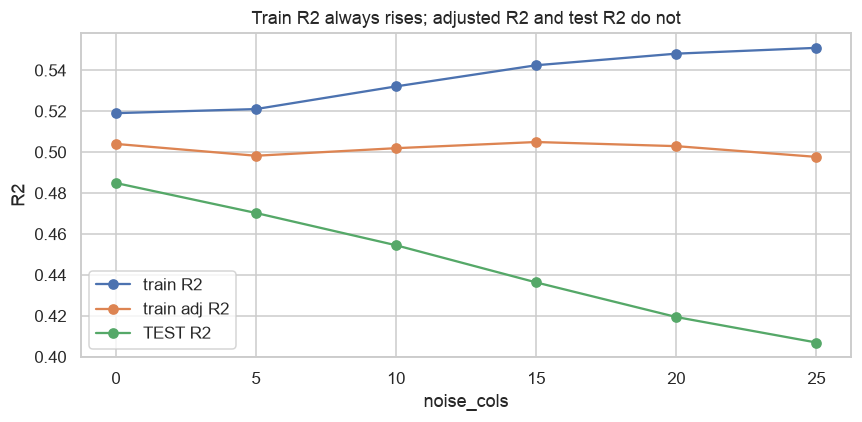

In [29]:
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score

X, yv = df_reg.drop(columns="y"), df_reg["y"]
Xtr, Xte, ytr, yte = train_test_split(X, yv, test_size=.25, random_state=42)

def adj_r2(r2, n, p):
    return 1 - (1 - r2) * (n - 1) / (n - p - 1)

# Add pure-noise columns one at a time and watch the two metrics diverge
rows = []
Xtr_a, Xte_a = Xtr.copy(), Xte.copy()
for k in range(0, 26, 5):
    if k:
        for j in range(5):
            col = f"noise_{k}_{j}"
            Xtr_a[col] = RNG.normal(size=len(Xtr_a))
            Xte_a[col] = RNG.normal(size=len(Xte_a))
    m = LinearRegression().fit(Xtr_a, ytr)
    r2_tr = m.score(Xtr_a, ytr)
    rows.append({"noise_cols": k,
                 "train R2": r2_tr,
                 "train adj R2": adj_r2(r2_tr, len(Xtr_a), Xtr_a.shape[1]),
                 "TEST R2": r2_score(yte, m.predict(Xte_a))})

res = pd.DataFrame(rows).set_index("noise_cols")
print(res.round(3))

res.plot(marker="o", figsize=(8, 4))
plt.title("Train R2 always rises; adjusted R2 and test R2 do not")
plt.ylabel("R2"); plt.tight_layout(); plt.show()

## Part D — ML Diagnostic Plots

Run the fitting cell below once; every subsequent plot depends on the objects it creates.

In [30]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression, LinearRegression
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

# --- Classification -----------------------------------------------------------
X, y = df_clf.drop(columns="y"), df_clf["y"]
X_tr, X_te, y_tr, y_te = train_test_split(
    X, y, test_size=.25, stratify=y, random_state=42)   # stratify keeps class balance in both splits

rf = RandomForestClassifier(n_estimators=300, random_state=42, n_jobs=-1).fit(X_tr, y_tr)
logit = Pipeline([("sc", StandardScaler()),
                  ("clf", LogisticRegression(max_iter=2000))]).fit(X_tr, y_tr)

# [:, 1] pulls the positive-class column; column order follows model.classes_
proba_rf = rf.predict_proba(X_te)[:, 1]
proba_lr = logit.predict_proba(X_te)[:, 1]
print("classes_ =", rf.classes_, "-> column 1 is P(class 1)")

# --- Regression ---------------------------------------------------------------
Xr, yr = df_reg.drop(columns="y"), df_reg["y"]
Xr_tr, Xr_te, yr_tr, yr_te = train_test_split(Xr, yr, test_size=.25, random_state=42)
lin = LinearRegression().fit(Xr_tr, yr_tr)
pred_lin = lin.predict(Xr_te)
resid = yr_te - pred_lin

classes_ = [0 1] -> column 1 is P(class 1)


### D1. Learning curve — bias vs variance

**What it shows.** Training and validation score as a function of how much training data was used.

**How to read it.** Four shapes, four actions:

| Shape | Diagnosis | Action |
|---|---|---|
| Both curves plateau at a **low** score, small gap | Underfitting (high bias) | More features, more model capacity, less regularisation. **More data will not help.** |
| Large persistent gap, training near-perfect | Overfitting (high variance) | More data, more regularisation, fewer features, simpler model |
| Validation still rising at the right edge | Data-limited | Collecting more data will pay off |
| Curves converged and flat | At the model's ceiling | Change the model or the features, not the sample size |

The single most useful reading: **if the curves have converged, more data is wasted effort.** That saves you weeks.

**Fails when.** The scoring metric is inappropriate — an accuracy-based learning curve on imbalanced data flatlines near the majority rate and tells you nothing. Use `scoring="roc_auc"` or `"average_precision"`.

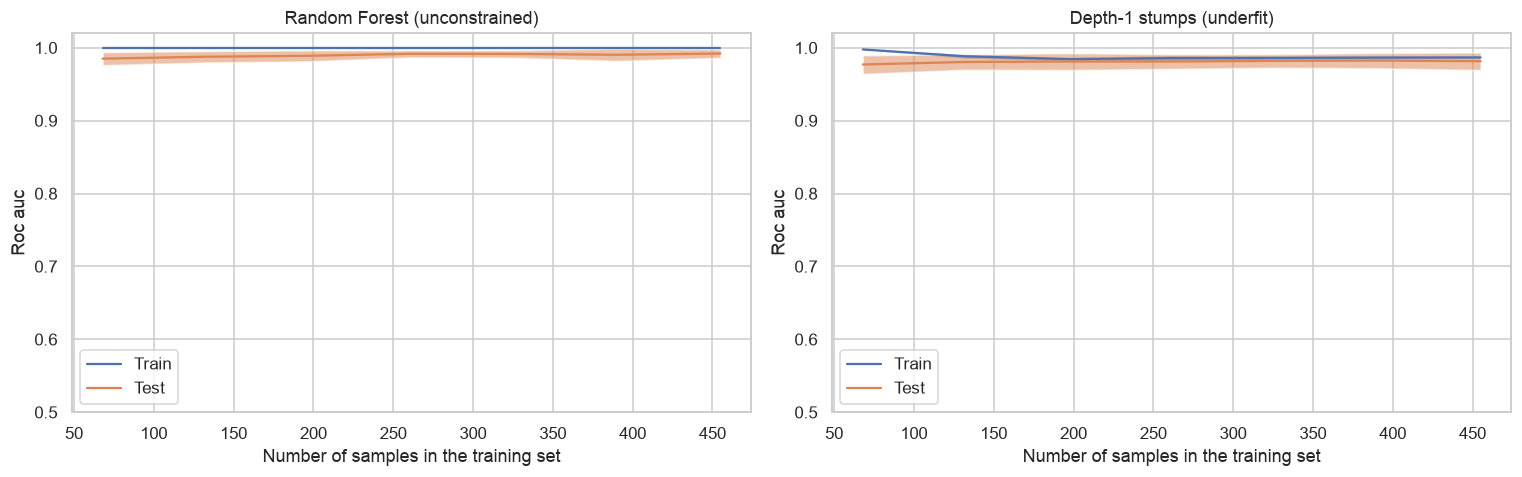

In [31]:
from sklearn.model_selection import LearningCurveDisplay

fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))

for ax, est, name in [
    (axes[0], RandomForestClassifier(n_estimators=150, random_state=42, n_jobs=-1),
     "Random Forest (unconstrained)"),
    (axes[1], RandomForestClassifier(n_estimators=150, max_depth=1, random_state=42, n_jobs=-1),
     "Depth-1 stumps (underfit)"),
]:
    LearningCurveDisplay.from_estimator(
        est, X, y,
        train_sizes=np.linspace(.15, 1.0, 7),
        cv=5,
        scoring="roc_auc",          # never use accuracy here on imbalanced data
        score_type="both",          # plot train AND validation
        n_jobs=-1, ax=ax, std_display_style="fill_between",
    )
    ax.set_title(name); ax.set_ylim(.5, 1.02)

plt.tight_layout(); plt.show()

### D2. Validation curve — hyperparameter sensitivity

**What it shows.** Train and validation score across a range of one hyperparameter, holding everything else fixed.

**How to read it.** The optimum is where the **validation** curve peaks, not where the training curve peaks. To the right of that peak the two curves separate — that separation point is where overfitting begins. A curve that is flat across the whole range means the parameter does not matter for this dataset; stop tuning it and spend the budget elsewhere.

**Fails when.**

- It varies one parameter at a time, so it cannot see interactions (`max_depth` and `min_samples_leaf` interact strongly). Use it to find *promising ranges*, then hand those ranges to a joint search (grid, random, or Optuna).
- Reading the peak off the training curve. The training curve improves monotonically with capacity and is not a model-selection signal.

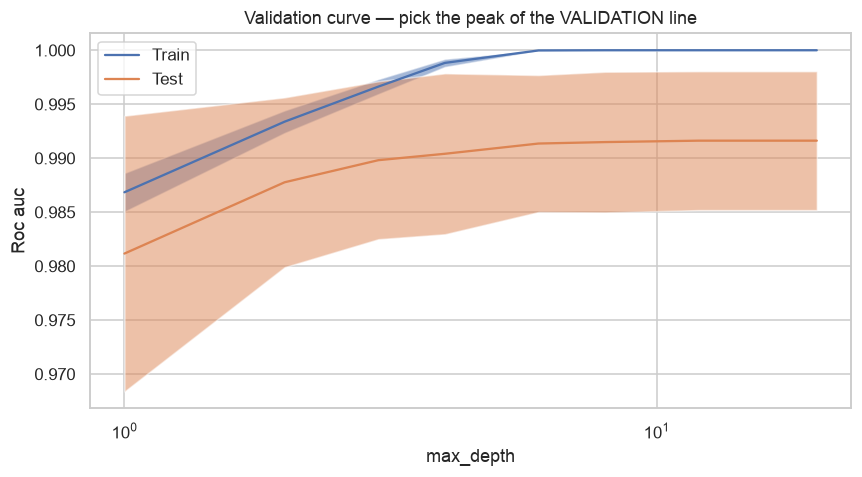

In [32]:
from sklearn.model_selection import ValidationCurveDisplay

fig, ax = plt.subplots(figsize=(8, 4.5))
ValidationCurveDisplay.from_estimator(
    RandomForestClassifier(n_estimators=120, random_state=42, n_jobs=-1),
    X, y,
    param_name="max_depth",
    param_range=[1, 2, 3, 4, 6, 8, 12, 20],
    cv=5, scoring="roc_auc", n_jobs=-1, ax=ax,
    std_display_style="fill_between",
)
ax.set_title("Validation curve — pick the peak of the VALIDATION line")
plt.tight_layout(); plt.show()

### D3. Confusion matrix — which errors you are making

**What it shows.** Counts of predicted vs actual class.

**How to read it.** The off-diagonal cells are the whole point. Ask which of the two error types is more expensive in the actual use case, then check whether the model is making the affordable one.

| Cell | Meaning | Cost driver |
|---|---|---|
| True positive | Correctly caught | — |
| False positive | False alarm | Wasted investigation, unnecessary intervention |
| False negative | Missed case | The defect ships / the problem escapes |
| True negative | Correctly passed | — |

**Always normalise by row** (`normalize="true"`). Row-normalised, the diagonal reads directly as per-class recall, and unequal class sizes stop distorting the picture.

**Fails when.**

- Raw counts on imbalanced data make the majority-class diagonal enormous and everything else look negligible.
- It is computed at the default 0.5 threshold, which is arbitrary. Regenerate it at your chosen operating threshold (D6) before drawing conclusions.

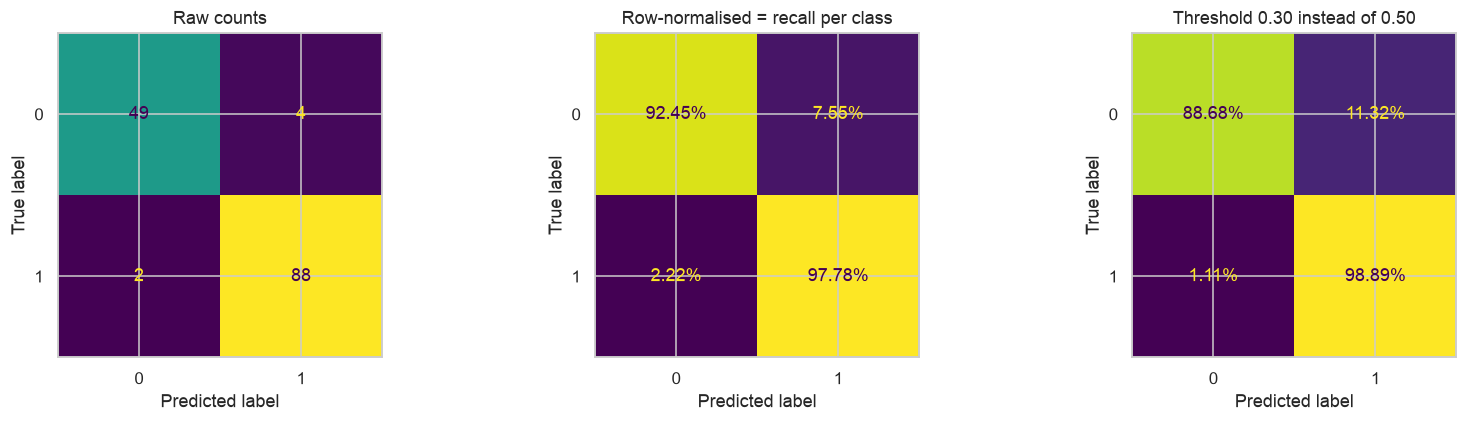

              precision    recall  f1-score   support

           0      0.961     0.925     0.942        53
           1      0.957     0.978     0.967        90

    accuracy                          0.958       143
   macro avg      0.959     0.951     0.955       143
weighted avg      0.958     0.958     0.958       143



In [33]:
from sklearn.metrics import ConfusionMatrixDisplay, classification_report

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

ConfusionMatrixDisplay.from_predictions(y_te, rf.predict(X_te), ax=axes[0], colorbar=False)
axes[0].set_title("Raw counts")

# normalize='true' divides by ROW total => diagonal reads as per-class recall
ConfusionMatrixDisplay.from_predictions(y_te, rf.predict(X_te), normalize="true",
                                        values_format=".2%", ax=axes[1], colorbar=False)
axes[1].set_title("Row-normalised = recall per class")

# Same model, threshold moved to 0.30 => more positives caught, more false alarms
ConfusionMatrixDisplay.from_predictions(y_te, (proba_rf >= .30).astype(int),
                                        normalize="true", values_format=".2%",
                                        ax=axes[2], colorbar=False)
axes[2].set_title("Threshold 0.30 instead of 0.50")

plt.tight_layout(); plt.show()
print(classification_report(y_te, rf.predict(X_te), digits=3))

### D4. ROC curve — ranking quality

**What it shows.** True positive rate against false positive rate across every possible threshold. AUC is the probability that a randomly chosen positive is scored above a randomly chosen negative.

**How to read it.** The curve is threshold-independent — it measures how well the model **ranks**, not how well it classifies at any particular cutoff. The diagonal is random. Steepness near the left edge is what you want: high recall achieved at low false-positive cost.

| ROC-AUC | Reading |
|---|---|
| 0.50 | No better than chance |
| 0.70–0.80 | Acceptable |
| 0.80–0.90 | Good |
| > 0.95 | Suspicious — check for leakage before celebrating |

**Fails when.** **Class imbalance.** FPR has the (large) negative count in its denominator, so thousands of false positives barely move the x-axis when negatives dominate. A model can post ROC-AUC of 0.95 and still be unusable at an 8% positive rate. Under imbalance, use D5.

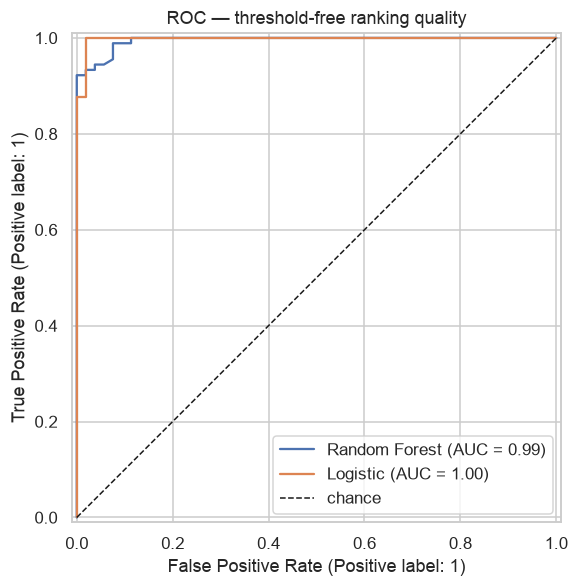

RF   ROC-AUC 0.9949
LR   ROC-AUC 0.9977


In [34]:
from sklearn.metrics import RocCurveDisplay, roc_auc_score

fig, ax = plt.subplots(figsize=(6.5, 5.5))
RocCurveDisplay.from_predictions(y_te, proba_rf, name="Random Forest", ax=ax)
RocCurveDisplay.from_predictions(y_te, proba_lr, name="Logistic", ax=ax)
ax.plot([0, 1], [0, 1], "k--", lw=1, label="chance")
ax.set_title("ROC — threshold-free ranking quality")
ax.legend(); plt.tight_layout(); plt.show()

print(f"RF   ROC-AUC {roc_auc_score(y_te, proba_rf):.4f}")
print(f"LR   ROC-AUC {roc_auc_score(y_te, proba_lr):.4f}")

### D5. Precision-recall curve — the honest view under imbalance

**What it shows.** Precision against recall across thresholds. Average precision (AP) is the area under it.

**Why it beats ROC under imbalance.** Precision has **predicted positives** in its denominator, not total negatives. Every false positive therefore hurts precision immediately, whereas it barely moves FPR when negatives are plentiful. PR shows the pain that ROC hides.

**How to read it.** The baseline is a horizontal line at the **positive prevalence**, not 0.5. Always draw it — an AP of 0.45 is excellent at 8% prevalence and mediocre at 40%. Read your operating point off the curve: pick the recall you need and see what precision it costs.

**Fails when.** Comparing AP across datasets with different prevalence, since the baseline moves. Compare AP against its own baseline (the lift), not against another dataset's AP.

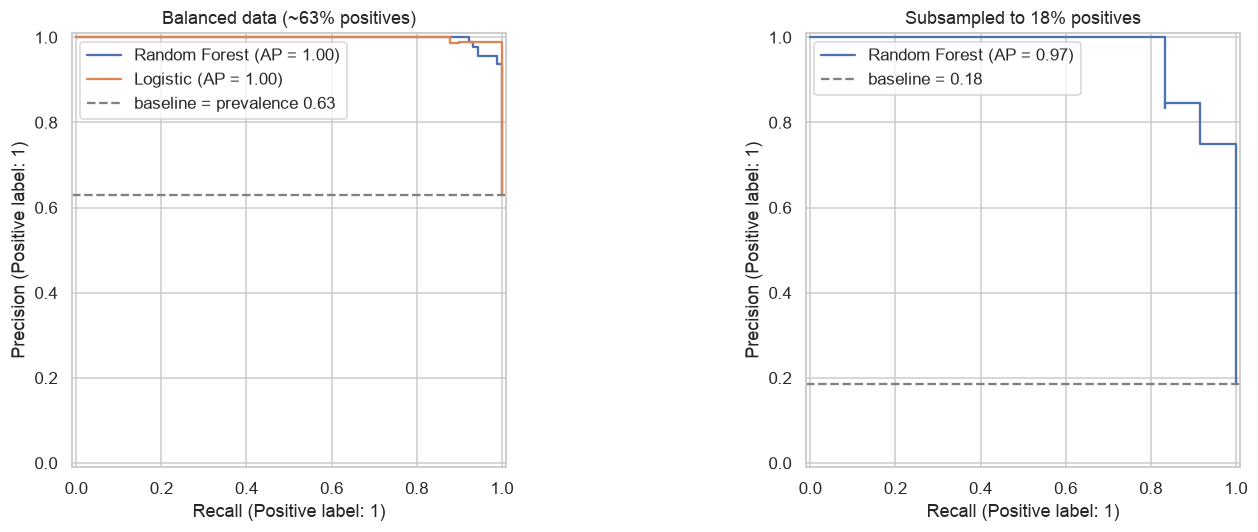

balanced   AP 0.997 (baseline 0.629)
imbalanced AP 0.966 (baseline 0.185)


In [35]:
from sklearn.metrics import PrecisionRecallDisplay, average_precision_score

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

PrecisionRecallDisplay.from_predictions(y_te, proba_rf, name="Random Forest", ax=axes[0])
PrecisionRecallDisplay.from_predictions(y_te, proba_lr, name="Logistic", ax=axes[0])
axes[0].axhline(y_te.mean(), ls="--", c="grey", label=f"baseline = prevalence {y_te.mean():.2f}")
axes[0].legend(); axes[0].set_title("Balanced data (~63% positives)")

# Imbalanced case: identical ranking, very different PR story
mask = (y_te == 1) | (RNG.random(len(y_te)) < 1.0)
yi = np.r_[y_te.values[y_te.values == 1][:12], y_te.values[y_te.values == 0]]
pi = np.r_[proba_rf[y_te.values == 1][:12], proba_rf[y_te.values == 0]]
PrecisionRecallDisplay.from_predictions(yi, pi, name="Random Forest", ax=axes[1])
axes[1].axhline(yi.mean(), ls="--", c="grey", label=f"baseline = {yi.mean():.2f}")
axes[1].legend(); axes[1].set_title(f"Subsampled to {yi.mean():.0%} positives")

plt.tight_layout(); plt.show()
print(f"balanced   AP {average_precision_score(y_te, proba_rf):.3f} (baseline {y_te.mean():.3f})")
print(f"imbalanced AP {average_precision_score(yi, pi):.3f} (baseline {yi.mean():.3f})")

### D6. Threshold sweep — choosing the operating point

**What it shows.** Precision, recall and F1 as functions of the decision threshold.

**Why it matters.** `.predict()` hard-codes a 0.5 cutoff. That is a default, not an optimum, and it is almost never the right business choice. Tuning the threshold costs nothing, requires no retraining, and is usually the largest single improvement available on an imbalanced problem.

**How to read it.** Precision and recall cross somewhere; that crossing maximises neither. Pick the threshold from the requirement, in this order of preference:

1. **A hard constraint** — "recall must be at least 95%": read the highest precision achievable at that recall.
2. **A cost model** — assign a cost to FP and FN and minimise expected cost.
3. **Only if neither exists** — maximise F1.

**Fails when.** The threshold is selected on the test set. That is selection leakage: your reported metric is now optimistic. Choose the threshold on a validation split or via cross-validation, then evaluate once on test.

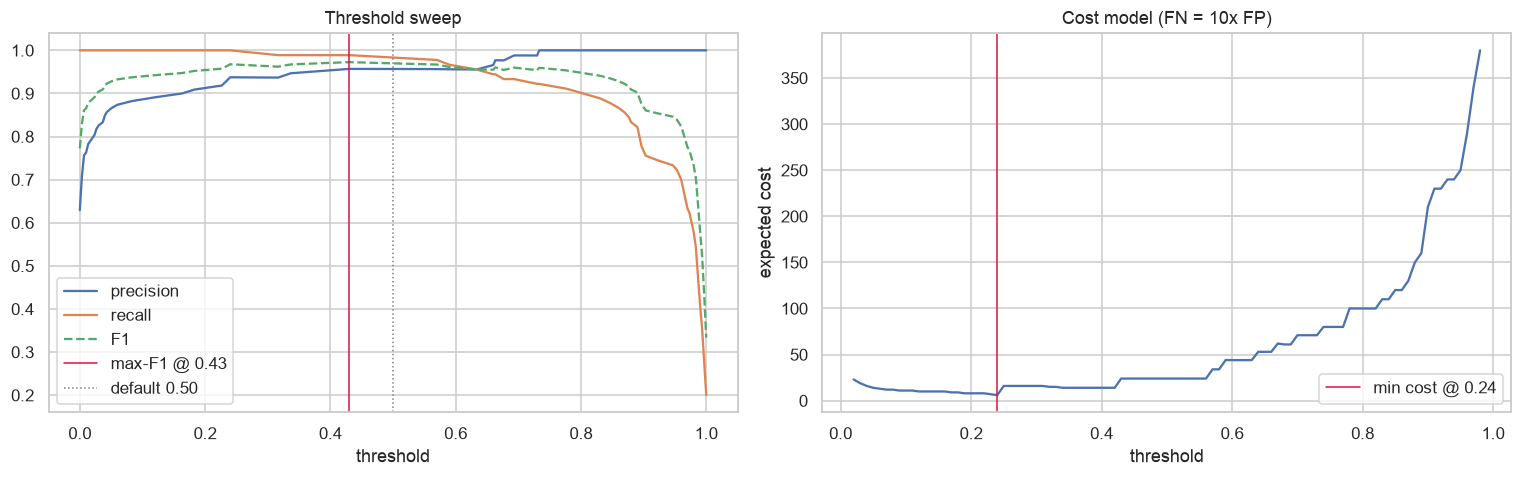

F1 @ 0.50 = 0.967
F1 @ best = 0.973


In [36]:
from sklearn.metrics import precision_recall_curve, f1_score

prec, rec, thr = precision_recall_curve(y_te, proba_rf)
f1 = 2 * prec * rec / (prec + rec + 1e-12)

fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))

axes[0].plot(thr, prec[:-1], label="precision")   # arrays are len(thr)+1
axes[0].plot(thr, rec[:-1],  label="recall")
axes[0].plot(thr, f1[:-1],   label="F1", ls="--")
best = thr[np.argmax(f1[:-1])]
axes[0].axvline(best, c="crimson", lw=1, label=f"max-F1 @ {best:.2f}")
axes[0].axvline(.5, c="grey", ls=":", lw=1, label="default 0.50")
axes[0].set_xlabel("threshold"); axes[0].legend(); axes[0].set_title("Threshold sweep")

# Cost-based selection: state the costs explicitly rather than defaulting to F1
C_FP, C_FN = 1.0, 10.0     # a missed positive costs 10x a false alarm
grid = np.linspace(.02, .98, 97)
cost = [((proba_rf >= t) & (y_te == 0)).sum() * C_FP +
        ((proba_rf < t) & (y_te == 1)).sum() * C_FN for t in grid]
axes[1].plot(grid, cost)
axes[1].axvline(grid[int(np.argmin(cost))], c="crimson", lw=1,
                label=f"min cost @ {grid[int(np.argmin(cost))]:.2f}")
axes[1].set_xlabel("threshold"); axes[1].set_ylabel("expected cost")
axes[1].legend(); axes[1].set_title(f"Cost model (FN = {C_FN:.0f}x FP)")

plt.tight_layout(); plt.show()
print(f"F1 @ 0.50 = {f1_score(y_te, (proba_rf >= .5).astype(int)):.3f}")
print(f"F1 @ best = {f1_score(y_te, (proba_rf >= best).astype(int)):.3f}")

### D7. Calibration curve — are the probabilities meaningful?

**What it shows.** Predicted probability (binned) against the observed frequency of positives in each bin. Perfect calibration is the diagonal: among rows scored 0.30, roughly 30% are actually positive.

**Why it matters.** Ranking and calibration are different properties. A model can rank perfectly (ROC-AUC 0.99) and still output probabilities that are systematically wrong. If anyone downstream multiplies your output by a cost, feeds it into an expected-value calculation, or reads it as "70% likely", calibration is required — ranking alone is not enough.

**How to read it.**

| Curve shape | Meaning | Fix |
|---|---|---|
| On the diagonal | Calibrated | Nothing |
| S-shape below then above | Overconfident — pushes scores to the extremes | Platt scaling (sigmoid) |
| Flattened toward the middle | Underconfident | Isotonic regression |
| Consistently above the diagonal | Systematically under-predicting the positive rate | Recalibrate |

Random Forest is typically underconfident (averaging over trees pulls scores toward the centre); boosted trees and SVMs tend to be overconfident.

**Fails when.** Too few bins hides miscalibration; too many makes each bin so small that the curve is pure noise. With small test sets use `strategy="quantile"` so each bin holds an equal number of rows.

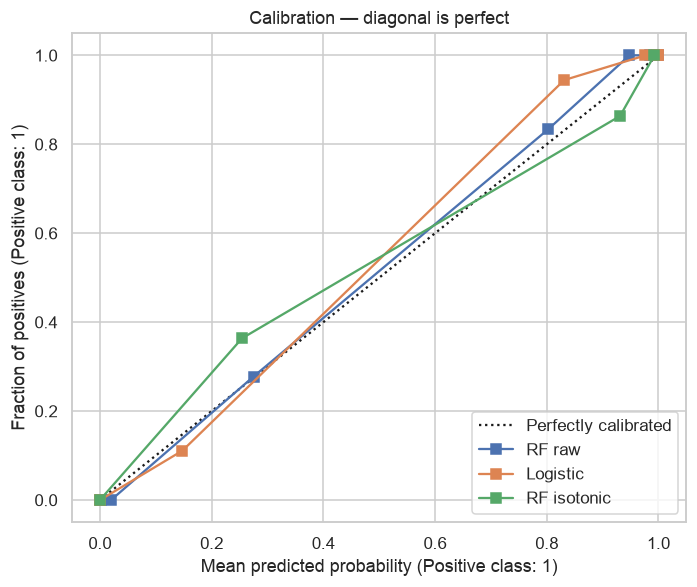

RF raw         Brier 0.0296
Logistic       Brier 0.0181
RF isotonic    Brier 0.0335


In [37]:
from sklearn.calibration import CalibrationDisplay, CalibratedClassifierCV
from sklearn.metrics import brier_score_loss

# Calibrate on the TRAINING data via internal CV, never on the test set
cal = CalibratedClassifierCV(
    RandomForestClassifier(n_estimators=200, random_state=42, n_jobs=-1),
    method="isotonic", cv=5).fit(X_tr, y_tr)
proba_cal = cal.predict_proba(X_te)[:, 1]

fig, ax = plt.subplots(figsize=(6.5, 5.5))
for p, name in [(proba_rf, "RF raw"), (proba_lr, "Logistic"), (proba_cal, "RF isotonic")]:
    CalibrationDisplay.from_predictions(y_te, p, n_bins=8, strategy="quantile",
                                        name=name, ax=ax)
ax.set_title("Calibration — diagonal is perfect")
plt.tight_layout(); plt.show()

# Brier score = mean squared error of the probabilities. Lower is better.
for p, name in [(proba_rf, "RF raw"), (proba_lr, "Logistic"), (proba_cal, "RF isotonic")]:
    print(f"{name:14s} Brier {brier_score_loss(y_te, p):.4f}")

### D8. Regression diagnostics — the four-panel check

Run all four together; each catches a different failure.

| Panel | Looks for | Bad sign |
|---|---|---|
| Residuals vs fitted | Unmodelled structure | Any curve, arch, or funnel instead of a flat random band |
| QQ plot of residuals | Non-normal errors | Ends bending away from the line |
| Scale-location (sqrt abs residual vs fitted) | Heteroscedasticity | An upward trend — error variance grows with the prediction |
| Predicted vs actual | Overall fit and bias | Points off the 45-degree line; compression at the extremes |

**What each implies.**

- **Curvature in residuals vs fitted** — you are missing a non-linear term. Add a polynomial, a spline, or move to a tree model.
- **Funnel shape** — heteroscedasticity. Coefficient estimates stay unbiased but standard errors and prediction intervals are wrong. Log-transform the target, or use weighted least squares.
- **Compression in predicted vs actual** — the classic regression-to-the-mean pattern: the model under-predicts highs and over-predicts lows. Usually means the model is too constrained.

**Fails when.** Diagnostics are computed on training residuals. Overfitted models produce beautiful training residual plots and terrible test ones. Use held-out residuals.

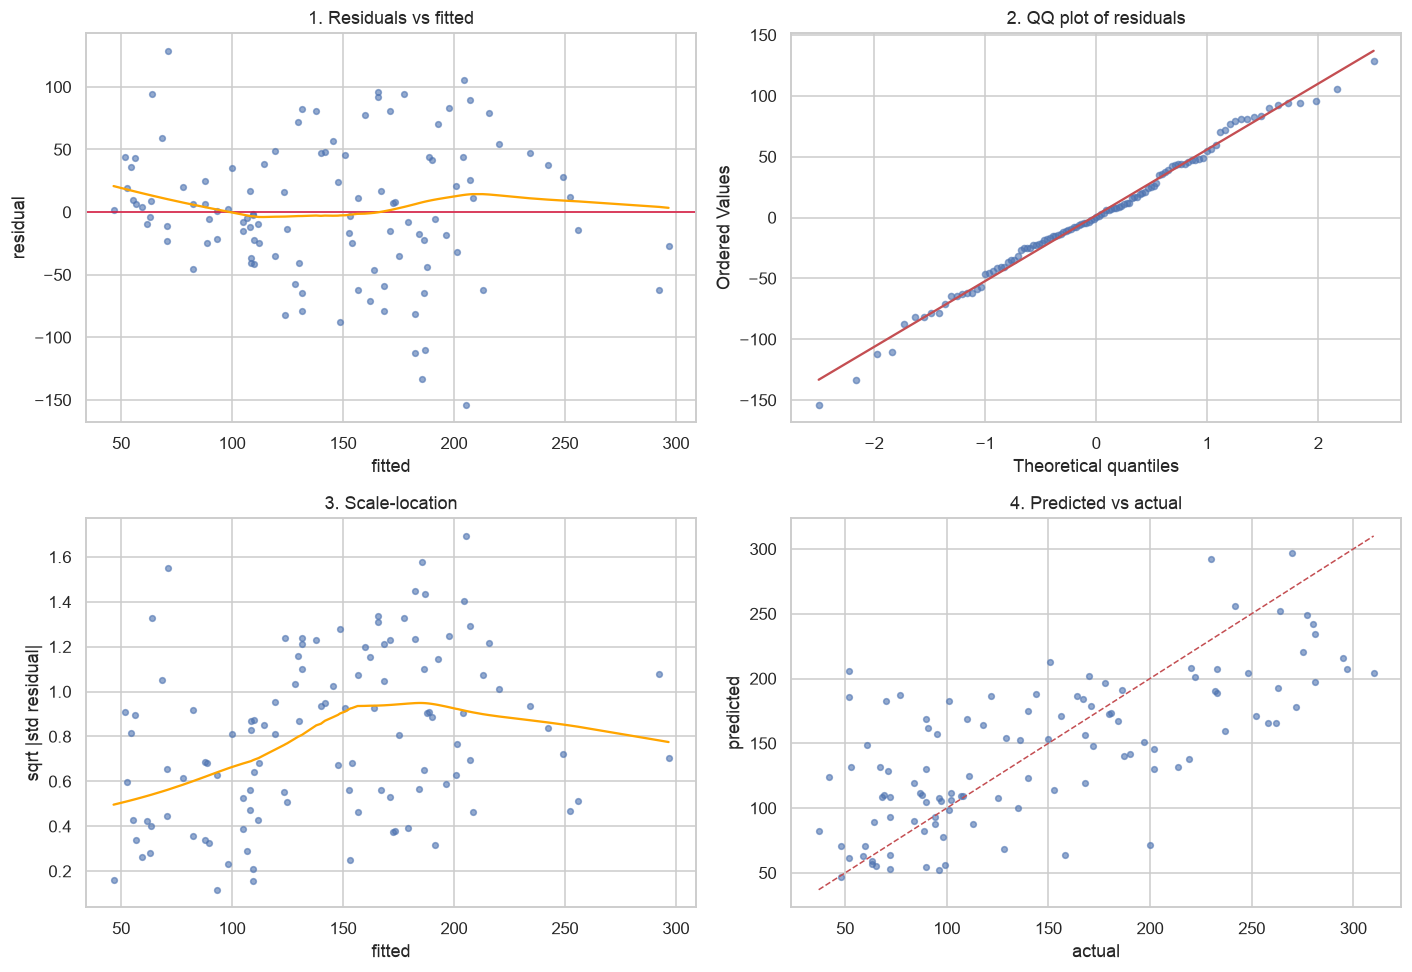

test R2   0.485
test MAE  41.55
test RMSE 53.37


In [38]:
fig, axes = plt.subplots(2, 2, figsize=(13, 9))

axes[0, 0].scatter(pred_lin, resid, s=14, alpha=.6)
axes[0, 0].axhline(0, c="crimson", lw=1)
sns.regplot(x=pred_lin, y=resid, lowess=True, scatter=False,
            line_kws={"color": "orange", "lw": 1.5}, ax=axes[0, 0])
axes[0, 0].set(xlabel="fitted", ylabel="residual", title="1. Residuals vs fitted")

stats.probplot(resid, dist="norm", plot=axes[0, 1])
axes[0, 1].set_title("2. QQ plot of residuals")
axes[0, 1].get_lines()[0].set(markersize=4, alpha=.6)

# Scale-location: sqrt of |standardised residual| vs fitted
std_res = resid / resid.std()
axes[1, 0].scatter(pred_lin, np.sqrt(np.abs(std_res)), s=14, alpha=.6)
sns.regplot(x=pred_lin, y=np.sqrt(np.abs(std_res)), lowess=True, scatter=False,
            line_kws={"color": "orange", "lw": 1.5}, ax=axes[1, 0])
axes[1, 0].set(xlabel="fitted", ylabel="sqrt |std residual|", title="3. Scale-location")

lo, hi = yr_te.min(), yr_te.max()
axes[1, 1].scatter(yr_te, pred_lin, s=14, alpha=.6)
axes[1, 1].plot([lo, hi], [lo, hi], "r--", lw=1)     # 45-degree reference
axes[1, 1].set(xlabel="actual", ylabel="predicted", title="4. Predicted vs actual")

plt.tight_layout(); plt.show()

from sklearn.metrics import r2_score, mean_absolute_error, root_mean_squared_error
print(f"test R2   {r2_score(yr_te, pred_lin):.3f}")
print(f"test MAE  {mean_absolute_error(yr_te, pred_lin):.2f}")
print(f"test RMSE {root_mean_squared_error(yr_te, pred_lin):.2f}")

### D9. Feature importance — three methods that disagree

| Method | What it measures | Watch out for |
|---|---|---|
| Impurity (`.feature_importances_`) | Total impurity reduction from splits on that feature | **Biased toward high-cardinality and continuous features.** Computed on training data. Free but least trustworthy |
| Permutation | Drop in a chosen metric when that column is shuffled | Model-agnostic, uses held-out data. **Splits credit between correlated features**, so both look unimportant |
| SHAP | Each feature's contribution to each individual prediction | Direction *and* magnitude, per row. Slow on large data. Requires `pip install shap` |

**How to read them.** Use impurity for a quick glance, permutation on the test set for the ranking you report, and SHAP when you need to explain *why* a specific prediction came out the way it did.

**Fails when.**

- **Correlated features.** If two features are near-duplicates, permuting one leaves the information available through the other, so both score near zero. Neither is unimportant — they are redundant. Check the correlation matrix (B11) before concluding a feature is useless.
- **Importance is not causation.** A feature can be important because it is a downstream consequence of the target, which is leakage.
- **A single dominant feature** with near-perfect importance is a leakage alarm, not a success.

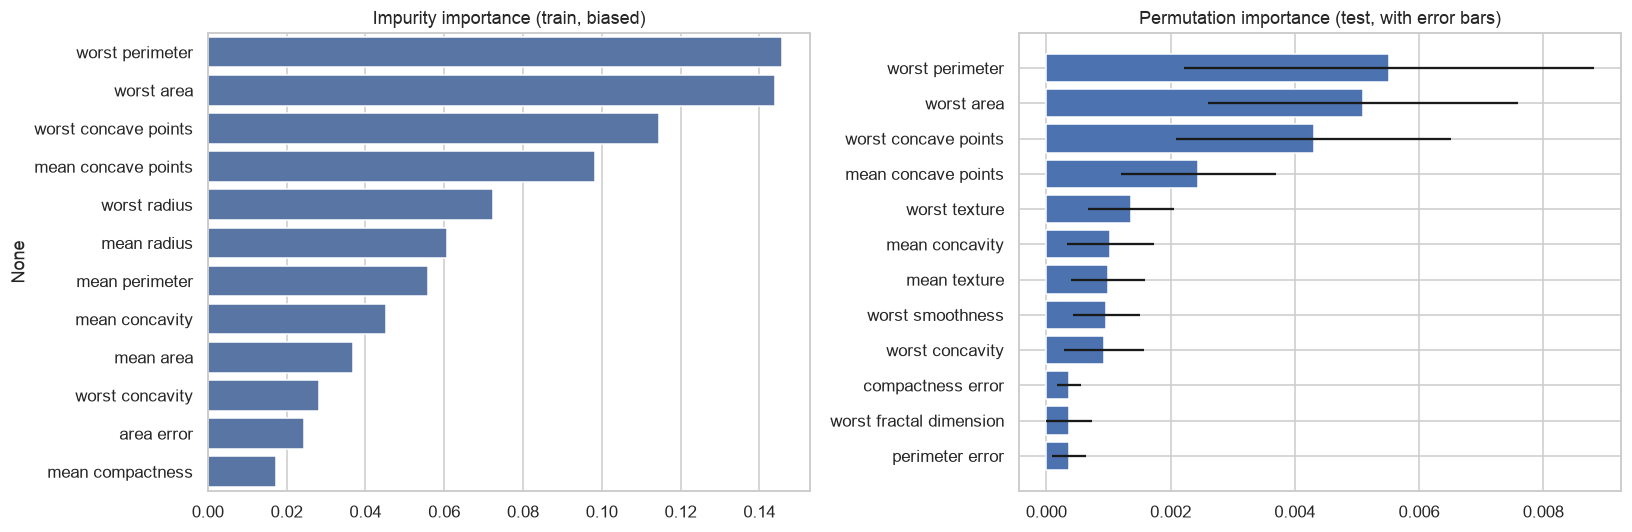

                   impurity_rank  perm_rank  shift
worst radius                 5.0       29.0   24.0
mean perimeter               7.0       30.0   23.0
mean radius                  6.0       25.0   19.0
mean area                    9.0       26.0   17.0
compactness error           26.0       10.0   16.0
symmetry error              30.0       16.0   14.0


In [39]:
from sklearn.inspection import permutation_importance

imp = pd.Series(rf.feature_importances_, index=X.columns).sort_values(ascending=False)

# n_repeats controls the noise floor; scoring should match your evaluation metric
perm = permutation_importance(rf, X_te, y_te, n_repeats=15,
                              random_state=42, n_jobs=-1, scoring="roc_auc")
perm_s = pd.Series(perm.importances_mean, index=X.columns).sort_values(ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(15, 5))
sns.barplot(x=imp.head(12).values, y=imp.head(12).index, ax=axes[0])
axes[0].set_title("Impurity importance (train, biased)")
axes[1].barh(perm_s.head(12).index[::-1], perm_s.head(12).values[::-1],
             xerr=perm.importances_std[np.argsort(-perm.importances_mean)][:12][::-1])
axes[1].set_title("Permutation importance (test, with error bars)")
plt.tight_layout(); plt.show()

# Rank disagreement between the two methods
cmp = pd.DataFrame({"impurity_rank": imp.rank(ascending=False),
                    "perm_rank": perm_s.rank(ascending=False)})
cmp["shift"] = (cmp["impurity_rank"] - cmp["perm_rank"]).abs()
print(cmp.sort_values("shift", ascending=False).head(6).round(0))

In [40]:
# SHAP — requires: pip install shap
import shap

expl = shap.TreeExplainer(rf)
sv = expl.shap_values(X_te.iloc[:150])
sv_pos = sv[..., 1] if np.ndim(sv) == 3 else sv     # binary RF returns one array per class

shap.summary_plot(sv_pos, X_te.iloc[:150], max_display=12, show=False)
plt.title("SHAP beeswarm — direction and magnitude per row")
plt.tight_layout(); plt.show()

ModuleNotFoundError: No module named 'shap'

### D10. Partial dependence and ICE — the shape of an effect

**What they show.**

- **PDP** — the average predicted outcome as one feature is varied across its range, marginalising over everything else. One line: the average effect.
- **ICE** — the same computation per row. One thin line per observation.

**How to read them.** The PDP shape tells you what functional form the model has learned: flat means no effect, monotone means a simple relationship, a step means a threshold the model found, an arch means an optimum.

**Always plot ICE alongside PDP** (`kind="both"`). If the ICE lines fan out or cross, the effect differs by subgroup and the average is hiding an interaction. In the extreme, half the rows trend up and half trend down, and the PDP is a flat line implying no effect at all.

**Fails when.**

- **Correlated features.** PDP evaluates the model at feature combinations that may never occur in reality (thickness = 300 while a correlated pressure stays at its median). Those extrapolated regions are unreliable. Check the rug marks along the x-axis — sparse data means an untrustworthy curve there.
- PDP shows what the **model** learned, not what is true in the world. A wrong model produces a confident, wrong PDP.

In [ ]:
from sklearn.inspection import PartialDependenceDisplay

top2 = perm_s.head(2).index.tolist()

fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))
PartialDependenceDisplay.from_estimator(
    rf, X_te, features=top2,
    kind="both",                 # 'both' = thin ICE lines + bold PDP average
    subsample=60, ice_lines_kw={"alpha": .2, "lw": .6},
    pd_line_kw={"color": "crimson", "lw": 2.5},
    ax=axes,
)
for ax in axes:
    ax.set_title(ax.get_xlabel())
plt.suptitle("PDP (red) over ICE (grey) — fanning means an interaction", y=1.03)
plt.tight_layout(); plt.show()

### D11. Optuna diagnostics — is the search working?

**Three plots, three questions.**

| Plot | Question | Action |
|---|---|---|
| Optimisation history | Has the best value plateaued? | Flat for the last third means stop; still climbing means extend |
| Parameter importances | Which parameters actually moved the score? | Freeze the unimportant ones, widen the range on the important ones |
| Slice plot | Where in each parameter's range did good trials cluster? | If the optimum sits at a range boundary, your range was too narrow — widen and rerun |

Use `optuna.visualization.matplotlib` rather than `optuna.visualization`; the latter requires plotly.

**Fails when.** Parameter importance is computed over the trials actually sampled. If the search concentrated in a narrow region, a parameter can look unimportant simply because it was never varied much. Read importance together with the slice plot.

In [ ]:
import optuna
from optuna.visualization.matplotlib import (plot_optimization_history,
                                             plot_param_importances, plot_slice)
from sklearn.model_selection import cross_val_score

import warnings
optuna.logging.set_verbosity(optuna.logging.WARNING)          # silence per-trial logging
warnings.filterwarnings("ignore", category=optuna.exceptions.ExperimentalWarning)

def objective(trial):
    params = {
        "n_estimators": trial.suggest_int("n_estimators", 80, 400, step=40),
        "max_depth":    trial.suggest_int("max_depth", 2, 16),
        "min_samples_leaf": trial.suggest_int("min_samples_leaf", 1, 12),
        "max_features": trial.suggest_float("max_features", .2, 1.0),
    }
    m = RandomForestClassifier(**params, random_state=42, n_jobs=-1)
    # CV inside the objective; never score a trial on the test set
    return cross_val_score(m, X_tr, y_tr, cv=4, scoring="roc_auc", n_jobs=-1).mean()

study = optuna.create_study(direction="maximize",
                            sampler=optuna.samplers.TPESampler(seed=42))
study.optimize(objective, n_trials=30, show_progress_bar=False)
print("best ROC-AUC:", round(study.best_value, 4))
print("best params :", study.best_params)

# These helpers build and return their own Axes, so they do not take ax=
# and cannot be placed into a pre-made subplot grid.
for fn in (plot_optimization_history, plot_param_importances):
    fn(study)
    plt.tight_layout(); plt.show()

plot_slice(study, params=["max_depth", "max_features"])
plt.tight_layout(); plt.show()

### D12. Clustering diagnostics — elbow, silhouette, dendrogram

**Elbow plot.** Within-cluster sum of squares (inertia) against k. Inertia always falls as k rises, so you look for the bend where the marginal gain drops off. The elbow is frequently ambiguous — treat it as an upper bound on k, not an answer.

**Silhouette.** Per point: `(b - a) / max(a, b)` where `a` is the mean distance to its own cluster and `b` to the nearest other cluster.

| Silhouette | Reading |
|---|---|
| Near +1 | Well inside its own cluster |
| Near 0 | On the boundary between two clusters |
| Negative | Probably assigned to the wrong cluster |

Read the **per-cluster plot**, not just the average. One wide, well-separated cluster can mask three bad ones in the mean.

**Dendrogram.** Merge height is the distance at which two groups joined. A long vertical stretch without merges is a natural cut point — cut there.

**Fails when.**

- **Unscaled features.** k-means is Euclidean, so the largest-range column dictates the clusters. Scale first, always.
- k-means assumes roughly spherical, similar-sized clusters. On elongated or nested shapes it fails regardless of what the elbow says. Cross-check on a PCA scatter (D13).
- Silhouette rewards spherical structure, so it will favour k-means solutions even when they are wrong for the geometry.

In [ ]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, silhouette_samples
from scipy.cluster.hierarchy import linkage, dendrogram

Xs = StandardScaler().fit_transform(X)      # scaling is mandatory before k-means

ks = range(2, 10)
inertia = [KMeans(k, n_init=10, random_state=42).fit(Xs).inertia_ for k in ks]
sil = [silhouette_score(Xs, KMeans(k, n_init=10, random_state=42).fit_predict(Xs)) for k in ks]

fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))

axes[0].plot(list(ks), inertia, "o-"); axes[0].set(xlabel="k", ylabel="inertia",
                                                   title="Elbow — an upper bound, not an answer")
axes[1].plot(list(ks), sil, "o-", c="crimson"); axes[1].set(xlabel="k", ylabel="mean silhouette",
                                                            title="Mean silhouette by k")

# Per-cluster silhouette: the reading the average hides
k = 2
labels = KMeans(k, n_init=10, random_state=42).fit_predict(Xs)
vals = silhouette_samples(Xs, labels)
low = 10
for c in range(k):
    cv = np.sort(vals[labels == c])
    axes[2].fill_betweenx(np.arange(low, low + len(cv)), 0, cv, alpha=.7)
    low += len(cv) + 10
axes[2].axvline(vals.mean(), c="crimson", ls="--", label=f"mean {vals.mean():.2f}")
axes[2].legend(); axes[2].set(xlabel="silhouette", title=f"Per-cluster silhouette (k={k})")

plt.tight_layout(); plt.show()

In [ ]:
# Dendrogram: cut where there is a long vertical gap between merges
Z = linkage(Xs[:120], method="ward")        # ward minimises within-cluster variance

plt.figure(figsize=(12, 4.5))
dendrogram(Z, truncate_mode="lastp", p=25, leaf_rotation=90, show_contracted=True)
plt.title("Dendrogram (Ward) — merge height = distance at which groups joined")
plt.ylabel("merge distance"); plt.tight_layout(); plt.show()

### D13. PCA — scree, cumulative variance, biplot

**Scree plot.** Explained variance ratio per component. Look for the elbow, or read off the cumulative curve how many components are needed to reach your variance target (80%, 90%, 95%).

**Cumulative variance.** The direct answer to "how many components do I keep?". Setting `PCA(n_components=0.95)` lets sklearn choose the count for you.

**Biplot.** Points are observations projected onto PC1 and PC2; arrows are the original features' loadings. Arrow direction shows which component a feature drives; arrow length shows how strongly. Arrows pointing the same way indicate correlated features — which is why PCA is a valid response to the multicollinearity found in C4.

**Fails when.**

- **Unscaled input.** PCA maximises variance, so a feature measured in a large unit captures PC1 purely because of its unit. Standardise first — this is not optional.
- **Components are not interpretable features.** PC1 is a weighted blend of everything. Using PCA before a model you need to explain to stakeholders trades away interpretability.
- PCA is **unsupervised** — it maximises variance in X, with no knowledge of y. The direction of greatest variance is not necessarily the direction that predicts the target. A low-variance component can carry all the signal.

In [ ]:
from sklearn.decomposition import PCA

pca = PCA().fit(Xs)
evr = pca.explained_variance_ratio_
cum = np.cumsum(evr)

fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))

axes[0].bar(range(1, 16), evr[:15])
axes[0].set(xlabel="component", ylabel="explained variance ratio", title="Scree plot")

axes[1].plot(range(1, len(cum) + 1), cum, "o-")
for t, c in [(.80, "orange"), (.90, "crimson"), (.95, "purple")]:
    axes[1].axhline(t, ls="--", lw=1, c=c)
    axes[1].annotate(f"{t:.0%} at {np.argmax(cum >= t) + 1} PCs",
                     (len(cum) * .45, t + .01), color=c, fontsize=9)
axes[1].set(xlabel="components", ylabel="cumulative variance", title="How many to keep")

# Biplot: scores as points, loadings as arrows
sc = pca.transform(Xs)[:, :2]
axes[2].scatter(sc[:, 0], sc[:, 1], c=y, cmap="coolwarm", s=10, alpha=.5)
for i in np.argsort(-np.abs(pca.components_[0]))[:6]:      # 6 strongest PC1 loadings
    axes[2].arrow(0, 0, pca.components_[0, i] * 9, pca.components_[1, i] * 9,
                  color="k", width=.02, head_width=.3)
    axes[2].text(pca.components_[0, i] * 10, pca.components_[1, i] * 10,
                 X.columns[i], fontsize=7)
axes[2].set(xlabel=f"PC1 ({evr[0]:.0%})", ylabel=f"PC2 ({evr[1]:.0%})", title="Biplot")

plt.tight_layout(); plt.show()
print(f"components for 95% variance: {np.argmax(cum >= .95) + 1} of {len(cum)}")

---

## Quick reference — the failure modes that bite most often

| Symptom | Likely cause | Section |
|---|---|---|
| Box plots look identical but models disagree | Bimodality hidden by the box plot | B2 |
| Minority class invisible in a KDE | `common_norm=True` | B8 |
| Correlation heatmap looks alarmingly red | Colour scale autoscaled; no `vmin`/`vmax` | B11 |
| Features look independent but coefficients are unstable | Multi-way collinearity; pairwise correlation missed it | C4 |
| Every normality test rejects | Large n — tests over-reject; read the QQ plot | C2 |
| 92% accuracy on a rare-event problem | Accuracy paradox; majority-class floor | C6 |
| Cross-validation score far above test score | Preprocessing or resampling fitted outside the Pipeline | C7, C6 |
| Model ranks well but probabilities are wrong | Uncalibrated; ROC does not measure calibration | D7 |
| ROC-AUC 0.95 but the model is useless in practice | Imbalance; use the PR curve | D4, D5 |
| Two known-good features both score zero importance | Correlated pair splitting the permutation credit | D9 |
| PDP flat although the feature clearly matters | Opposing subgroup effects cancelling in the average | D10 |
| Clusters track one feature only | Features not scaled before k-means | D12 |
| More data does not improve the model | Curves already converged — it is a bias problem | D1 |